# Original GMU Static–Dynamic Crime Forecasting (No GNN)

This notebook preserves the original data loading, feature extraction, smoothing,
normalization, temporal split, node split utilities, and PyG datasets. Only the
model and post-model analyses are replaced.

The model uses the established **Gated Multimodal Unit (GMU)** to fuse static
socioeconomic features and a dynamic crime window at every node. The resulting
joint node representation is passed directly to an MLP regressor; no graph layer is used.


## Architecture

For node $i$ at window $t$:

$$
\mathbf{h}^{s}_{i}=\tanh(W_s\mathbf{x}^{s}_{i}+b_s),\qquad
\mathbf{h}^{d}_{i,t}=\tanh(W_d\mathbf{x}^{d}_{i,t}+b_d),
$$

$$
\mathbf{z}_{i,t}=\sigma\left(W_z[\mathbf{x}^{s}_{i}\Vert
\mathbf{x}^{d}_{i,t}]+b_z\right),
$$

$$
\mathbf{h}^{GMU}_{i,t}=\mathbf{z}_{i,t}\odot\mathbf{h}^{s}_{i}
+(1-\mathbf{z}_{i,t})\odot\mathbf{h}^{d}_{i,t}.
$$

$\mathbf{z}_{i,t}$ is a feature-wise gate: values near 1 favor the static
representation and values near 0 favor the dynamic representation. The fused
representation is passed directly to an MLP regressor. There is no graph message
passing in this original GMU-only baseline.


## What remains unchanged

- Static and dynamic feature selection
- Exponential smoothing and log transformation
- Train-only normalization
- Sliding-window dataset construction
- Existing temporal and node-split setup

The replacement section contains the GMU-GNN, leakage-free fixed-epoch training,
evaluation, gate analysis, modality ablation, neighborhood time-series plots,
gradient sensitivity, and embedding visualization.


In [1]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, SAGEConv, GATConv, GraphConv
from torch_geometric.data import Data
import optuna
import pandas as pd
import numpy as np
import torch.nn as nn
import os
import matplotlib.pyplot as plt
import re
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from sklearn.manifold import TSNE


from helper_funcs import *
from plots import *
from models import *
from model_helper_funcs import *
from model_fusion_scratch import *
from torch_geometric.loader import DataLoader


c:\Users\waqar\AppData\Local\pypoetry\Cache\virtualenvs\data-fusion-r9UYRqEp-py3.12\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Configuration


In [2]:
seed = 42
set_seed(seed)

num_epochs = 50

data_set = "real"         # "real" | "artificial"
type_graph_conv = 'GMU_orig'  # StaticDynamicGNN_hidden "SAGE" | "GCN" | "GAT" | "FWAGCN" | "EFWAGCN" | "GraphConv" |DualGNN | StaticDynamicGNN_adv
architecture = "2_layers"

# if type_graph_conv == 'SAGE':
#     graph_conv = SAGEConv
# elif type_graph_conv == "GCN":
#     graph_conv = GCNConv
# elif type_graph_conv == "GAT":
#     graph_conv = GATConv
# elif type_graph_conv == "FWAGCN":
#     graph_conv = FeatureWiseGraphConv
# elif type_graph_conv == "EFWAGCN":
#     graph_conv = EdgeFeatureAttentionGCN
# elif type_graph_conv == "GraphConv":
#     graph_conv = GraphConv
# elif type_graph_conv == "DualGNN":
#     graph_conv = DualGNN
    
    
model_used = "GMU_orig_inductive_learning"     

output_folder = f"results/inductive_learning/{model_used}/{type_graph_conv}/{architecture}"
os.makedirs(output_folder, exist_ok=True)

# Load dataset

In [3]:
if data_set == "artificial":
    print("Using artificial dataset")
    name_file_dataset = os.path.join("datasets", "artificial_data_12_clusters_full.csv")
else:
    print("Using real dataset")
    name_file_dataset = "datasets/datasubset_nodes_waqar.csv"

df_nodes = pd.read_csv(name_file_dataset)
df_edges = pd.read_csv("datasets/aristas_subgrafoSPdaily.csv")
edge_index = map_edges_new_index(df_nodes, df_edges)

Using real dataset
tensor([[    573641,     573641,     573643,  ..., 8751085661, 8753316632,
         8795904828],
        [ 465879071,  292424978,  292424978,  ..., 8751085667, 8753316633,
         8795904831]])


d:\data_fusion\helper_funcs.py:50: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  edges_mapeados = df_edges.applymap(lambda x: mapping_dict.get(x, x)).values


edge_index_mapeado ------->  tensor([[    0,     0,     1,  ..., 14575, 14578, 14596],
        [ 5698,  1381,  1381,  ..., 14576, 14579, 14597]])


In [4]:
df_nodes.shape

(14640, 159)

# Label nodes

In [5]:
df_nodes_label = label_crime_nodes(df_nodes, threshold=6)
crime_label_col = "crime_label"
num_nodes = df_nodes_label.shape[0]

In [6]:
# plot_crime_vs_nocrime_ratio(df_nodes_label)

# Extract feature groups

In [7]:
df_nodes_label.columns

Index(['Nodo', '2006.01', '2006.02', '2006.03', '2006.04', '2006.05',
       '2006.06', '2006.07', '2006.08', '2006.09',
       ...
       'maiores_de_65_anos_taxa', 'Pontos_de_onibus', 'Estacao_de_metro',
       'Estacao_de_trem', 'Terminal_de_onibus', 'Favela_proxima', 'lat',
       'long', 'total_crimes', 'crime_label'],
      dtype='object', length=161)

In [8]:
dynamic_cols = [col for col in df_nodes_label.columns if re.match(r'^\d{4}\.\d{2}$', col)]
dynamic_dt = df_nodes_label[dynamic_cols]

cols_to_drop = dynamic_cols + ['Nodo', 'Pontos_de_onibus', 'lat', 'long', 'total_crimes', 'crime_label']
static_dt = df_nodes_label.drop(columns=cols_to_drop)

In [9]:
crime_label_col = df_nodes_label['crime_label']
crime_label_col

0        1
1        1
2        1
3        1
4        0
        ..
14635    0
14636    0
14637    0
14638    0
14639    0
Name: crime_label, Length: 14640, dtype: int64

In [10]:
static_dt.shape

(14640, 11)

# Normalize features


# Smooth dynamic data

In [11]:
dynamic_dt_smooth = dynamic_dt.apply(lambda row: row.ewm(alpha=0.1).mean(), axis=1)
dynamic_dt_smooth_log = np.log1p(np.array(dynamic_dt_smooth))

# global_min = dynamic_dt_smooth_log.min().min()
# global_max = dynamic_dt_smooth_log.max().max()
# dynamic_dt_norm = pd.DataFrame((dynamic_dt_smooth_log - global_min) / (global_max - global_min))

dynamic_dt_smooth_log = pd.DataFrame(dynamic_dt_smooth_log)
static_dt = pd.DataFrame(static_dt)

# scaler = MinMaxScaler()

# static_dt_norm = pd.DataFrame(scaler.fit_transform(static_dt))

# Convert to tensors

In [12]:
dynamic_tensor = torch.tensor(dynamic_dt_smooth_log.values, dtype=torch.float32)
dynamic_tensor = torch.nan_to_num(dynamic_tensor, nan=0.0)

static_tensor = torch.tensor(static_dt.values, dtype=torch.float32)
static_tensor = torch.nan_to_num(static_tensor, nan=0.0)

In [13]:
print(dynamic_tensor.shape)
print(static_tensor.shape)

torch.Size([14640, 144])
torch.Size([14640, 11])


# Sliding Window approach

In [14]:
# # Time split
TRAIN_END = 100
T = dynamic_tensor.size(1)
W = 5

# train_dataset = CrimeWindowPyGDataset(
# # train_dataset = CrimeWindowDataset(
#     static_tensor, dynamic_tensor, edge_index,
#     window_size=W,
#     start_t=0,
#     end_t=TRAIN_END
# )

# test_dataset = CrimeWindowPyGDataset(
# # test_dataset = CrimeWindowDataset(
#     static_tensor, dynamic_tensor, edge_index,
#     window_size=W,
#     start_t=TRAIN_END,
#     end_t=T
# )

# Inductive Learning

In [15]:
import torch

def filter_and_reindex(data, allowed_nodes):

    # ---- Step 1: mask nodes ----
    mask = torch.isin(data.node_ids, allowed_nodes)

    if mask.sum() == 0:
        return None

    # ---- Step 2: filter node features ----
    new_x_static = data.x_static[mask]
    new_x_dynamic = data.x_dynamic[mask]
    new_y = data.y[mask]

    # IMPORTANT: keep original node ids temporarily
    old_node_ids = data.node_ids[mask]

    # ---- Step 3: create mapping old → new index ----
    # Example: {5:0, 10:1, 20:2}
    unique_nodes = old_node_ids
    mapping = {int(old_id): i for i, old_id in enumerate(unique_nodes)}

    # ---- Step 4: filter edges ----
    src, dst = data.edge_index

    edge_mask = torch.isin(src, old_node_ids) & torch.isin(dst, old_node_ids)

    src = src[edge_mask]
    dst = dst[edge_mask]

    # ---- Step 5: reindex edges ----
    new_src = torch.tensor([mapping[int(s)] for s in src])
    new_dst = torch.tensor([mapping[int(d)] for d in dst])

    new_edge_index = torch.stack([new_src, new_dst], dim=0)

    # ---- Step 6: create new node ids (0...N-1) ----
    new_node_ids = torch.arange(len(unique_nodes))

    # ---- Step 7: update time_id ----
    new_time_id = data.time_id[mask]

    # ---- Step 8: return new Data ----
    new_data = data.clone()

    new_data.x_static = new_x_static
    new_data.x_dynamic = new_x_dynamic
    new_data.y = new_y
    new_data.edge_index = new_edge_index
    new_data.node_ids = new_node_ids   # ✅ reindexed
    new_data.time_id = new_time_id
    new_data.num_nodes = len(new_node_ids)

    return new_data

from torch.utils.data import Dataset

class InductiveWrapperDataset(Dataset):
    def __init__(self, base_dataset, allowed_nodes):
        self.base_dataset = base_dataset
        self.allowed_nodes = allowed_nodes

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):

        data = self.base_dataset[idx]

        new_data = filter_and_reindex(data, self.allowed_nodes)

        # Handle rare empty case
        if new_data is None:
            return self.__getitem__((idx + 1) % len(self))

        return new_data
    
    import numpy as np

def split_nodes(num_nodes, train_ratio=0.8, seed=42):
    np.random.seed(seed)

    nodes = np.arange(num_nodes)
    np.random.shuffle(nodes)

    split = int(train_ratio * num_nodes)

    train_nodes = torch.tensor(nodes[:split])
    test_nodes = torch.tensor(nodes[split:])

    return train_nodes, test_nodes

## Split nodes

In [16]:
train_nodes, test_nodes = split_nodes(static_tensor.shape[0])

## Compute normalization ONLY from TRAIN

Dynamic normalization

In [17]:
train_dynamic = dynamic_tensor[train_nodes][:, :TRAIN_END]

min_val = train_dynamic.min()
max_val = train_dynamic.max()

dynamic_tensor_norm = (dynamic_tensor - min_val) / (max_val - min_val + 1e-8)

In [18]:
dynamic_tensor.max()

tensor(3.8104)

Static normalization

In [19]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_static = static_tensor[train_nodes]

scaler.fit(train_static)

static_tensor_norm = torch.tensor(
    scaler.transform(static_tensor),
    dtype=torch.float32
)

Temporal Split

In [20]:
train_dataset = CrimeWindowPyGDataset(
    static_tensor_norm,
    dynamic_tensor_norm,
    edge_index,
    window_size=W,
    start_t=0,
    end_t=TRAIN_END
)

test_dataset = CrimeWindowPyGDataset(
    static_tensor_norm,
    dynamic_tensor_norm,
    edge_index,
    window_size=W,
    start_t=TRAIN_END,
    end_t=T
)

# Inductive Split on nodes

In [21]:

# train_dataset = InductiveWrapperDataset(train_dataset, train_nodes)
# test_dataset = InductiveWrapperDataset(test_dataset, test_nodes)

In [22]:
sample = train_dataset[0]

print(sample.x_static.shape)
print(sample.edge_index.max(), sample.num_nodes)

torch.Size([14640, 11])
tensor(14639) 14640


In [23]:
sample = test_dataset[0]

print(sample.x_dynamic.shape)
print(sample.edge_index.max(), sample.num_nodes)

torch.Size([14640, 5])
tensor(14639) 14640


# Original GMU fusion model (No GNN)

The GMU is applied independently at every node and time window. Its fused
representation is passed directly to an MLP regressor. `edge_index` is accepted
only for interface compatibility and is not used. This is the original GMU-only
baseline, not GMU-GNN.


In [24]:
import torch
import torch.nn as nn


class GatedMultimodalUnit(nn.Module):
    """Original feature-wise GMU for static and dynamic modalities."""

    def __init__(self, static_dim, dynamic_dim, hidden_dim):
        super().__init__()
        self.static_encoder = nn.Linear(static_dim, hidden_dim)
        self.dynamic_encoder = nn.Linear(dynamic_dim, hidden_dim)
        self.gate_layer = nn.Linear(static_dim + dynamic_dim, hidden_dim)
        self.reset_parameters()

    def reset_parameters(self):
        for layer in (
            self.static_encoder,
            self.dynamic_encoder,
            self.gate_layer,
        ):
            nn.init.xavier_uniform_(layer.weight)
            nn.init.zeros_(layer.bias)

    def forward(self, x_static, x_dynamic):
        h_static = torch.tanh(self.static_encoder(x_static))
        h_dynamic = torch.tanh(self.dynamic_encoder(x_dynamic))
        gate_static = torch.sigmoid(
            self.gate_layer(torch.cat([x_static, x_dynamic], dim=-1))
        )
        h_fused = (
            gate_static * h_static
            + (1.0 - gate_static) * h_dynamic
        )
        return h_fused, gate_static, h_static, h_dynamic


class GMUForecastModel(nn.Module):
    """Original GMU fusion followed by an MLP regressor; no GNN layer."""

    def __init__(self, static_dim, dynamic_dim, hidden_dim=64, dropout=0.2):
        super().__init__()
        self.gmu = GatedMultimodalUnit(
            static_dim=static_dim,
            dynamic_dim=dynamic_dim,
            hidden_dim=hidden_dim,
        )
        self.regressor = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    def forward(self, x_static, x_dynamic, edge_index=None, return_details=False):
        # edge_index is intentionally accepted only to keep every existing
        # training and analysis function unchanged. GMU does not use the graph.
        h_gmu, gate, h_static, h_dynamic = self.gmu(
            x_static,
            x_dynamic,
        )
        prediction = self.regressor(h_gmu).squeeze(-1)

        if return_details:
            return prediction, h_gmu, {
                "gate": gate,
                "h_static": h_static,
                "h_dynamic": h_dynamic,
                "h_gmu": h_gmu,
            }
        return prediction, h_gmu


# Model initialization


In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
S = static_tensor.size(1)

model = GMUForecastModel(
    static_dim=S,
    dynamic_dim=W,
    hidden_dim=64,
    dropout=0.2,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

print(model)
print("Device:", device)
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))


GMUForecastModel(
  (gmu): GatedMultimodalUnit(
    (static_encoder): Linear(in_features=11, out_features=64, bias=True)
    (dynamic_encoder): Linear(in_features=5, out_features=64, bias=True)
    (gate_layer): Linear(in_features=16, out_features=64, bias=True)
  )
  (regressor): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)
Device: cpu
Trainable parameters: 10689


# Training

Because the supplied preprocessing creates only training and test datasets,
the model is trained for the configured fixed number of epochs. The test set is
not used for early stopping or checkpoint selection.


In [26]:
def _move_batch(data, device):
    return data.to(device)


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_nodes = 0
    static_gate_sum = 0.0
    gate_elements = 0

    for data in loader:
        data = _move_batch(data, device)
        optimizer.zero_grad()
        prediction, _, details = model(
            data.x_static, data.x_dynamic, data.edge_index, return_details=True
        )
        target = data.y.float().view_as(prediction)
        loss = criterion(prediction, target)
        loss.backward()
        optimizer.step()

        n = target.numel()
        total_loss += loss.item() * n
        total_nodes += n
        static_gate_sum += details["gate"].detach().sum().item()
        gate_elements += details["gate"].numel()

    return total_loss / max(total_nodes, 1), static_gate_sum / max(gate_elements, 1)


train_loss_history = []
static_gate_history = []

for epoch in range(num_epochs):
    train_loss, static_gate_mean = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )
    train_loss_history.append(train_loss)
    static_gate_history.append(static_gate_mean)

    if epoch == 0 or (epoch + 1) % 10 == 0 or epoch + 1 == num_epochs:
        print(
            f"Epoch {epoch + 1:03d}/{num_epochs} | "
            f"Train MSE: {train_loss:.6f} | "
            f"GMU static gate: {static_gate_mean:.4f} | "
            f"dynamic gate: {1.0-static_gate_mean:.4f}"
        )


Epoch 001/50 | Train MSE: 0.002976 | GMU static gate: 0.5013 | dynamic gate: 0.4987
Epoch 010/50 | Train MSE: 0.000206 | GMU static gate: 0.4862 | dynamic gate: 0.5138
Epoch 020/50 | Train MSE: 0.000134 | GMU static gate: 0.4795 | dynamic gate: 0.5205
Epoch 030/50 | Train MSE: 0.000104 | GMU static gate: 0.4735 | dynamic gate: 0.5265
Epoch 040/50 | Train MSE: 0.000090 | GMU static gate: 0.4686 | dynamic gate: 0.5314
Epoch 050/50 | Train MSE: 0.000083 | GMU static gate: 0.4648 | dynamic gate: 0.5352


### Easy explanation — GMU training output

**Purpose.** Training MSE shows how well GMU fits the training examples. The static and
dynamic gates show its average modality balance during learning.

Training MSE fell from **0.002976** to **0.000083**, so GMU learned smoothly and had almost
converged by epoch 50. Its average static gate decreased from 0.501 to 0.465. Therefore,
training gradually shifted the gate toward dynamic crime history.

**Compared with M11.** GMU reached a low loss in 50 epochs, whereas normalized M11 required
about 100 epochs. GMU is smaller (10,689 parameters versus M11's 36,033) and easier to
optimize. This does not by itself make its fusion more informative.


# Training and gate-history plots


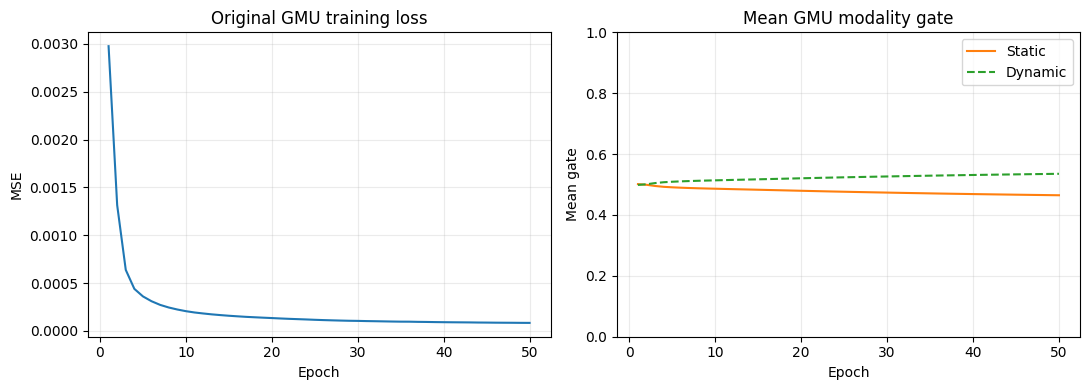

In [27]:
epochs = np.arange(1, len(train_loss_history) + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(epochs, train_loss_history, color="tab:blue")
axes[0].set(title="Original GMU training loss", xlabel="Epoch", ylabel="MSE")
axes[0].grid(alpha=0.25)

axes[1].plot(epochs, static_gate_history, label="Static", color="tab:orange")
axes[1].plot(
    epochs, 1.0 - np.asarray(static_gate_history),
    label="Dynamic", color="tab:green", linestyle="--"
)
axes[1].set(title="Mean GMU modality gate", xlabel="Epoch", ylabel="Mean gate", ylim=(0, 1))
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_training_and_gate_history.png"), dpi=300, bbox_inches="tight")
plt.show()


### Easy explanation — training curves

**Left plot.** The rapidly decreasing loss means GMU learns most of its forecasting pattern
within the first 10–20 epochs. The later flat section suggests convergence.

**Right plot.** Static weight decreases and dynamic weight increases. This agrees with recent
crime history being the main forecasting signal.

**GMU versus M11.** GMU's mean gate moves smoothly but stays soft. M11's mean gates also stay
near 0.5, but its individual dimensions later show much stronger specialization. Therefore,
GMU is easier to train; M11 learns a more complex gating structure.


# Test evaluation and collection


In [28]:
@torch.no_grad()
def evaluate_and_collect_gmu(model, loader, device, ablation=None):
    model.eval()
    predictions_per_time = []
    targets_per_time = []
    embeddings_per_time = []
    gates_per_time = []
    node_ids_per_time = []
    time_ids_per_time = []

    for step, data in enumerate(loader):
        data = _move_batch(data, device)
        x_static = data.x_static
        x_dynamic = data.x_dynamic

        if ablation == "static_only":
            x_dynamic = torch.zeros_like(x_dynamic)
        elif ablation == "dynamic_only":
            x_static = torch.zeros_like(x_static)

        prediction, embedding, details = model(
            x_static, x_dynamic, data.edge_index, return_details=True
        )
        target = data.y.float().view_as(prediction)

        n = target.numel()
        node_ids = getattr(data, "node_ids", torch.arange(n, device=device)).reshape(-1)
        time_ids = getattr(data, "time_id", torch.tensor(step, device=device)).reshape(-1)
        if node_ids.numel() == 1 and n > 1:
            node_ids = node_ids.repeat(n)
        if time_ids.numel() == 1 and n > 1:
            time_ids = time_ids.repeat(n)

        predictions_per_time.append(prediction.detach().cpu().numpy())
        targets_per_time.append(target.detach().cpu().numpy())
        embeddings_per_time.append(embedding.detach().cpu())
        gates_per_time.append(details["gate"].detach().cpu())
        node_ids_per_time.append(node_ids.detach().cpu())
        time_ids_per_time.append(time_ids.detach().cpu())

    y_pred = np.concatenate(predictions_per_time)
    y_true = np.concatenate(targets_per_time)
    error = y_pred - y_true
    mse = float(np.mean(error ** 2))
    mae = float(np.mean(np.abs(error)))
    variance = float(np.sum((y_true - y_true.mean()) ** 2))
    r2 = float(1.0 - np.sum(error ** 2) / variance) if variance > 0 else float("nan")

    metrics = {
        "MSE": mse,
        "RMSE": float(np.sqrt(mse)),
        "MAE": mae,
        "R2": r2,
    }
    details = {
        "predictions_per_time": predictions_per_time,
        "targets_per_time": targets_per_time,
        "embeddings_per_time": embeddings_per_time,
        "gates_per_time": gates_per_time,
        "gates": torch.cat(gates_per_time, dim=0),
        "node_ids": torch.cat(node_ids_per_time),
        "time_ids": torch.cat(time_ids_per_time),
    }
    return metrics, details


metrics, test_results = evaluate_and_collect_gmu(model, test_loader, device)
preds_per_t = test_results["predictions_per_time"]
targets_per_t = test_results["targets_per_time"]

display(pd.DataFrame([metrics]))
pd.DataFrame(list(metrics.items()), columns=["Metric", "Value"]).to_csv(
    os.path.join(output_folder, "metrics_GMU_GNN.csv"), index=False
)


,MSE,RMSE,MAE,R2
0,0.000054,0.007357,0.003739,0.981342


### Easy explanation — predictive performance

**Metric meanings.** MSE and RMSE penalize prediction errors, MAE is the average absolute
error, and R² measures explained target variation. Lower error and higher R² are better.

GMU obtains **MSE 0.000054, RMSE 0.007357, MAE 0.003739, and R² 0.981342**. This is a very
strong result.

**Compared with M11 (100-epoch normalized run):**

| Metric | Original GMU | M11 | Better |
|---|---:|---:|---|
| MSE | **0.000054** | 0.000065 | GMU |
| RMSE | **0.007357** | 0.008044 | GMU |
| MAE | **0.003739** | 0.005234 | GMU |
| R² | **0.981342** | 0.977696 | GMU |

GMU has about **17% lower MSE** and **29% lower MAE**. Thus GMU is the better forecaster in
these saved single runs. Confirm this using matched seeds before making a statistical
superiority claim.


# GMU modality contribution

The GMU has a feature-wise gate. For summaries, the gate is averaged over the
hidden dimensions. These values describe the model's learned mixing mechanism;
they are not causal importance scores.


Global mean static gate : 0.4644
Global mean dynamic gate: 0.5356


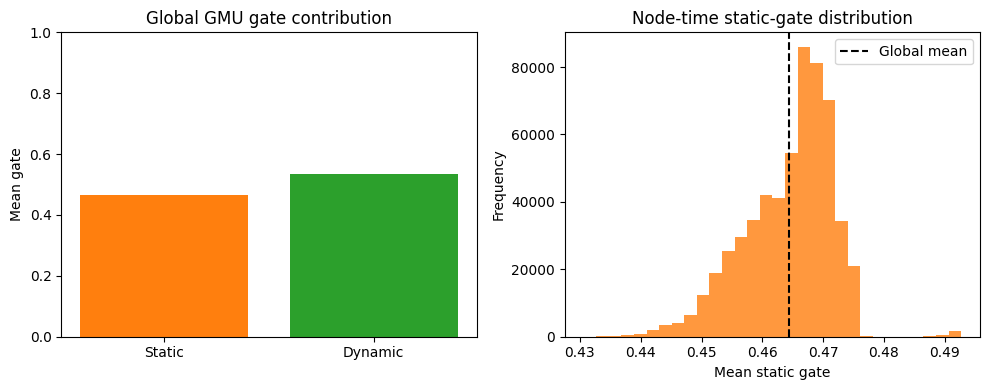

In [29]:
gates = test_results["gates"]                         # [all node-time cases, hidden_dim]
case_static_gate = gates.mean(dim=1)                 # scalar summary per node-time case
global_static_gate = case_static_gate.mean().item()
global_dynamic_gate = 1.0 - global_static_gate

print(f"Global mean static gate : {global_static_gate:.4f}")
print(f"Global mean dynamic gate: {global_dynamic_gate:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(["Static", "Dynamic"], [global_static_gate, global_dynamic_gate],
            color=["tab:orange", "tab:green"])
axes[0].set(title="Global GMU gate contribution", ylabel="Mean gate", ylim=(0, 1))

axes[1].hist(case_static_gate.numpy(), bins=30, color="tab:orange", alpha=0.8)
axes[1].axvline(global_static_gate, color="black", linestyle="--", label="Global mean")
axes[1].set(title="Node-time static-gate distribution", xlabel="Mean static gate", ylabel="Frequency")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_global_gate_analysis.png"), dpi=300, bbox_inches="tight")
plt.show()


### Easy explanation — global GMU gate

**Purpose.** This summarizes the single GMU gate. A static gate of 1 would select static
information; 0 would select dynamic information.

The mean is **0.464 static / 0.536 dynamic**, so GMU has a small average preference for
dynamic history. Most node-time mean gates are concentrated around 0.44–0.48.

**Compared with M11.** M11 has separate self and neighbor gates (0.489 and 0.481). Their
global means are also near balance. A direct mean comparison is limited because GMU has one
pre-regression gate while M11 has two role-specific gates inside graph message passing.


# Spatial and temporal gate analysis


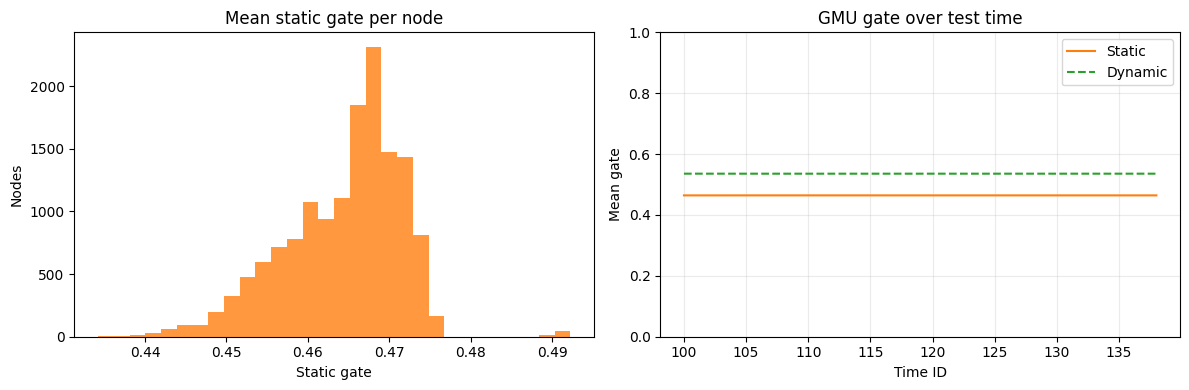

In [30]:
gate_frame = pd.DataFrame({
    "node_id": test_results["node_ids"].numpy(),
    "time_id": test_results["time_ids"].numpy(),
    "static_gate": case_static_gate.numpy(),
})
gate_frame["dynamic_gate"] = 1.0 - gate_frame["static_gate"]

node_gate = gate_frame.groupby("node_id", as_index=False)[["static_gate", "dynamic_gate"]].mean()
time_gate = gate_frame.groupby("time_id", as_index=False)[["static_gate", "dynamic_gate"]].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(node_gate["static_gate"], bins=30, color="tab:orange", alpha=0.8)
axes[0].set(title="Mean static gate per node", xlabel="Static gate", ylabel="Nodes")

axes[1].plot(time_gate["time_id"], time_gate["static_gate"], label="Static", color="tab:orange")
axes[1].plot(time_gate["time_id"], time_gate["dynamic_gate"], label="Dynamic", color="tab:green", linestyle="--")
axes[1].set(title="GMU gate over test time", xlabel="Time ID", ylabel="Mean gate", ylim=(0, 1))
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_spatial_temporal_gate_analysis.png"), dpi=300, bbox_inches="tight")
plt.show()

gate_frame.to_csv(os.path.join(output_folder, "gmu_gate_node_time_values.csv"), index=False)


### Easy explanation — spatial and temporal GMU means

**Left plot.** Each bar summarizes a street segment's average gate. The narrow distribution
means most nodes use a similar global static/dynamic balance.

**Right plot.** The citywide gate remains almost flat across test time. GMU does not make a
large citywide modality switch.

**Compared with M11.** Both models have flat global time means. M11 has greater within-node
and feature-wise variation, especially in its self gate. M11 therefore provides stronger
evidence of conditional adaptation; GMU is more stable but less adaptive.


# Representative dynamic-, balanced-, and static-heavy nodes


{'Dynamic-heavy': 11893, 'Balanced': 12949, 'Static-heavy': 12949}


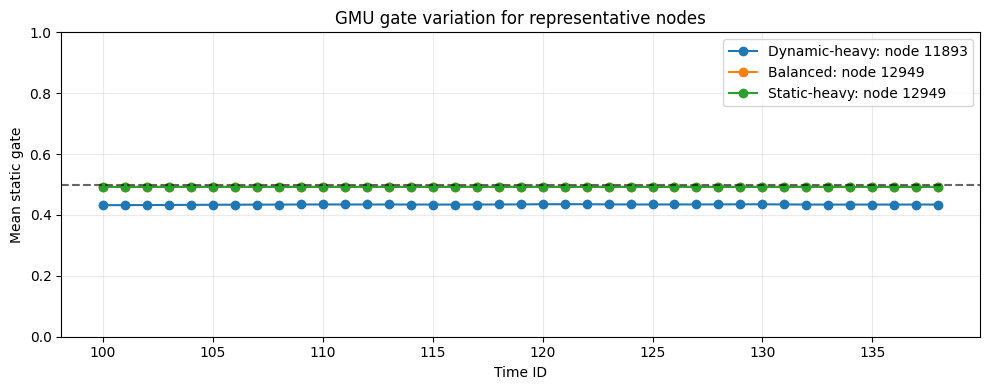

In [31]:
node_gate_sorted = node_gate.sort_values("static_gate").reset_index(drop=True)
dynamic_heavy_node = int(node_gate_sorted.iloc[0]["node_id"])
balanced_node = int(node_gate_sorted.iloc[(node_gate_sorted["static_gate"] - 0.5).abs().argmin()]["node_id"])
static_heavy_node = int(node_gate_sorted.iloc[-1]["node_id"])

selected_nodes = {
    "Dynamic-heavy": dynamic_heavy_node,
    "Balanced": balanced_node,
    "Static-heavy": static_heavy_node,
}
print(selected_nodes)

plt.figure(figsize=(10, 4))
for label, node in selected_nodes.items():
    series = gate_frame[gate_frame["node_id"] == node].sort_values("time_id")
    plt.plot(series["time_id"], series["static_gate"], marker="o", label=f"{label}: node {node}")
plt.axhline(0.5, color="black", linestyle="--", alpha=0.6)
plt.xlabel("Time ID")
plt.ylabel("Mean static gate")
plt.title("GMU gate variation for representative nodes")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_representative_node_gates.png"), dpi=300, bbox_inches="tight")
plt.show()


### Easy explanation — representative GMU nodes

**Purpose.** This shows the lowest observed mean static gate, the value closest to 0.5, and
the highest observed mean static gate.

Nodes 12949 are selected for both “balanced” and “static-heavy.” This means there is no truly
static-heavy node under the current definition; the highest observed gate is merely the
closest available value. All three lines are nearly flat.

**Compared with M11.** M11 identified different most-dynamic, balanced, and most-static nodes
and showed somewhat greater variation. M11 is more suitable for studying node-specific
fusion behavior. These labels remain descriptive, not statistically defined classes.


# Modality ablation

`Static only` zeros the dynamic input, while `Dynamic only` zeros the static
input. The already-trained full model is not retrained; this measures input
ablation sensitivity. For a stronger paper experiment, also train separate
static-only and dynamic-only models from scratch.


,Input,MSE,RMSE,MAE,R2
0,Full GMU,0.000054,0.007357,0.003739,0.981342
1,Static only,0.003668,0.060560,0.028427,-0.264131
2,Dynamic only,0.000084,0.009157,0.004216,0.971101


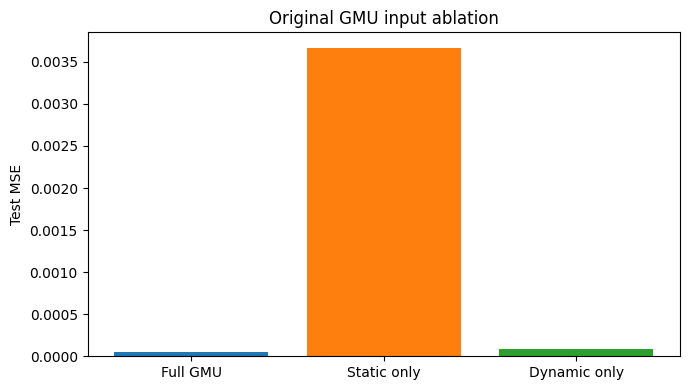

In [32]:
static_metrics, _ = evaluate_and_collect_gmu(model, test_loader, device, ablation="static_only")
dynamic_metrics, _ = evaluate_and_collect_gmu(model, test_loader, device, ablation="dynamic_only")

ablation_results = pd.DataFrame([
    {"Input": "Full GMU", **metrics},
    {"Input": "Static only", **static_metrics},
    {"Input": "Dynamic only", **dynamic_metrics},
])
display(ablation_results)
ablation_results.to_csv(os.path.join(output_folder, "gmu_ablation_results.csv"), index=False)

plt.figure(figsize=(7, 4))
plt.bar(ablation_results["Input"], ablation_results["MSE"],
        color=["tab:blue", "tab:orange", "tab:green"])
plt.ylabel("Test MSE")
plt.title("Original GMU input ablation")
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_ablation_mse.png"), dpi=300, bbox_inches="tight")
plt.show()


### Easy explanation — modality ablation

**Purpose.** One modality is zeroed in the trained model to test whether prediction depends
on it.

- Full GMU MSE: **0.000054**
- Dynamic-only intervention: **0.000084**
- Static-only intervention: **0.003668**, with negative R²

Dynamic data is the main predictor. Still, adding static information reduces MSE from
0.000084 to 0.000054—about a **36% relative reduction**—so static context is useful in the
full GMU.

**Compared with M11.** M11 improves from 0.000130 dynamic-only to 0.000065 full, a **50%
relative reduction**. GMU has better absolute errors, but M11 shows stronger relative
multimodal complementarity. These are post-training zeroing interventions; separately trained
unimodal baselines are still needed.


# Gradient sensitivity check


In [33]:
def gradient_sensitivity(model, data, device):
    model.eval()
    data = data.to(device)
    x_static = data.x_static.detach().clone().requires_grad_(True)
    x_dynamic = data.x_dynamic.detach().clone().requires_grad_(True)
    prediction, _ = model(x_static, x_dynamic, data.edge_index)
    prediction.mean().backward()
    return {
        "Static mean |gradient|": x_static.grad.abs().mean().item(),
        "Dynamic mean |gradient|": x_dynamic.grad.abs().mean().item(),
    }


gradient_results = gradient_sensitivity(model, next(iter(test_loader)), device)
display(pd.DataFrame([gradient_results]))


,Static mean |gradient|,Dynamic mean |gradient|
0,6.075160e-07,0.000013


### Easy explanation — gradient sensitivity

**Purpose.** Gradients measure how strongly a very small input change would locally affect
the prediction.

GMU's dynamic gradient is about **0.000013**, while the static gradient is approximately
0.00000061. Dynamic sensitivity is roughly 21 times larger. This confirms that recent crime
history drives local prediction changes.

**Compared with M11.** M11's ratio is roughly 24:1. Both models therefore agree that dynamic
inputs are the primary local signal. Absolute gradients should not be compared directly
across architectures because their internal scales differ.


# Predicted time-series and neighborhood analysis


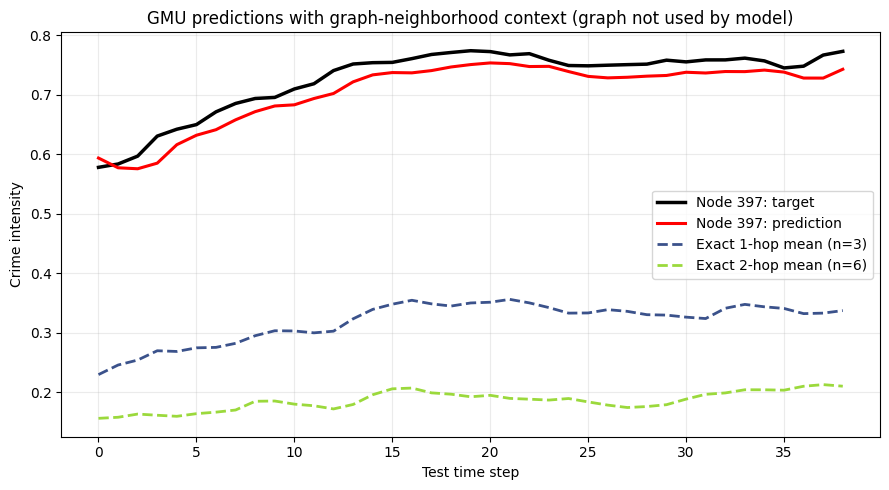

In [34]:
def adjacency_from_edge_index(edge_index, num_nodes):
    adjacency = {i: set() for i in range(num_nodes)}
    src, dst = edge_index.detach().cpu().numpy()
    for u, v in zip(src, dst):
        adjacency[int(u)].add(int(v))
        adjacency[int(v)].add(int(u))
    return adjacency


def exact_hop_nodes(center, adjacency, hop):
    visited = {center}
    frontier = {center}
    for _ in range(hop):
        next_frontier = set()
        for node in frontier:
            next_frontier.update(adjacency.get(node, set()))
        next_frontier -= visited
        visited |= next_frontier
        frontier = next_frontier
    return sorted(frontier)


def plot_neighborhood_prediction(pred_matrix, target_matrix, center_node, adjacency,
                                 max_hop=2, output_path=None):
    time = np.arange(pred_matrix.shape[0])
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(time, target_matrix[:, center_node], color="black", linewidth=2.5,
            label=f"Node {center_node}: target")
    ax.plot(time, pred_matrix[:, center_node], color="red", linewidth=2.2,
            label=f"Node {center_node}: prediction")

    colors = plt.cm.viridis(np.linspace(0.25, 0.85, max_hop))
    for hop, color in zip(range(1, max_hop + 1), colors):
        nodes = exact_hop_nodes(center_node, adjacency, hop)
        if nodes:
            mean_series = pred_matrix[:, nodes].mean(axis=1)
            ax.plot(time, mean_series, linestyle="--", linewidth=2, color=color,
                    label=f"Exact {hop}-hop mean (n={len(nodes)})")

    ax.set(xlabel="Test time step", ylabel="Crime intensity",
           title="GMU predictions with graph-neighborhood context (graph not used by model)")
    ax.legend()
    ax.grid(alpha=0.25)
    fig.tight_layout()
    if output_path:
        fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


pred_matrix = np.stack(preds_per_t)
target_matrix = np.stack(targets_per_t)
sample_graph = test_dataset[0]
adjacency = adjacency_from_edge_index(sample_graph.edge_index, pred_matrix.shape[1])

# Select the node with the highest mean target crime in the test period.
selected_node = int(np.argmax(target_matrix.mean(axis=0)))
plot_neighborhood_prediction(
    pred_matrix, target_matrix, selected_node, adjacency, max_hop=2,
    output_path=os.path.join(output_folder, "gmu_high_crime_node_neighborhood.png")
)


### Easy explanation — GMU prediction with graph-neighborhood context

The red GMU prediction follows the selected node's black target closely. One-hop and two-hop
node averages are lower, showing that this chosen node is a local high-crime case.

**Critical limitation.** GMU does not use `edge_index`; the hop curves are added only after
prediction for contextual visualization. They do not show that GMU learned neighborhood
information.

**Compared with M11.** M11 actually performs graph message passing, so neighborhood context
is part of its model. M11 is better when the research question concerns spatial interaction.
GMU may still forecast this particular node more accurately using only node-level inputs.


# Prediction scatter and residual analysis


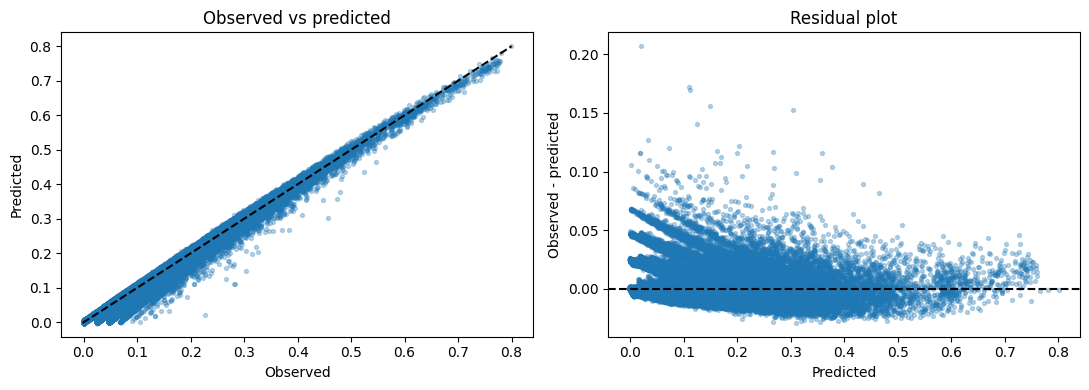

In [35]:
y_true = target_matrix.reshape(-1)
y_pred = pred_matrix.reshape(-1)
residual = y_true - y_pred

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(y_true, y_pred, s=8, alpha=0.3)
lo = min(y_true.min(), y_pred.min())
hi = max(y_true.max(), y_pred.max())
axes[0].plot([lo, hi], [lo, hi], color="black", linestyle="--")
axes[0].set(title="Observed vs predicted", xlabel="Observed", ylabel="Predicted")

axes[1].scatter(y_pred, residual, s=8, alpha=0.3)
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set(title="Residual plot", xlabel="Predicted", ylabel="Observed - predicted")

plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_prediction_diagnostics.png"), dpi=300, bbox_inches="tight")
plt.show()


### Easy explanation — observed/predicted and residual plots

Most points lie very close to the diagonal, matching GMU's high R². The residual cloud is
centered near zero, although its spread changes with predicted crime and some large positive
errors occur. High-crime cases remain more difficult.

**Compared with M11.** GMU has lower global MSE, RMSE and MAE, so its prediction cloud is
numerically closer overall. Both models show non-constant residual spread. GMU is better for
forecast accuracy in this run; neither completely solves extreme-crime prediction.


# Explainability

In [36]:
import numpy as np
import pandas as pd
import torch


def _expand_metadata(value, number_of_nodes, device):
    """
    Convert scalar node/time metadata into one value per node.
    """
    if value is None:
        return None

    value = value.reshape(-1)

    if value.numel() == 1 and number_of_nodes > 1:
        value = value.repeat(number_of_nodes)

    return value


@torch.no_grad()
def collect_gate_explainability(
    model,
    loader,
    device,
    model_type,
):
    """
    Collect gate values and crime information.

    Parameters
    ----------
    model:
        Complete trained model.

    loader:
        PyG test or training loader.

    device:
        'cpu', 'cuda', or torch.device.

    model_type:
        One of:
        - 'gmu'
        - 'gmu_gnn'
        - 'm11_vector'

    Returns
    -------
    Dictionary containing node/time IDs, crime intensity,
    target crime, predictions, and gate summaries.
    """

    valid_types = {
        "gmu",
        "gmu_gnn",
        "m11_vector",
    }

    if model_type not in valid_types:
        raise ValueError(
            f"model_type must be one of {valid_types}"
        )

    model.eval()
    device = torch.device(device)

    all_node_ids = []
    all_time_ids = []
    all_input_crime = []
    all_target_crime = []
    all_predictions = []

    # GMU gate
    all_gate_static = []
    all_gate_vectors = []

    # M11 gates
    all_gate_self = []
    all_gate_neigh = []
    all_gate_self_vectors = []
    all_gate_neigh_vectors = []

    for step, data in enumerate(loader):
        data = data.to(device)

        output = model(
            data.x_static,
            data.x_dynamic,
            data.edge_index,
            return_details=True,
        )

        prediction, embedding, details = output
        prediction = prediction.reshape(-1)

        number_of_nodes = prediction.numel()

        # -----------------------------
        # Node IDs
        # -----------------------------
        node_ids = getattr(
            data,
            "node_ids",
            torch.arange(
                number_of_nodes,
                device=device,
            ),
        )

        node_ids = _expand_metadata(
            node_ids,
            number_of_nodes,
            device,
        )

        # -----------------------------
        # Time IDs
        # -----------------------------
        time_ids = getattr(
            data,
            "time_id",
            torch.tensor(
                step,
                device=device,
            ),
        )

        time_ids = _expand_metadata(
            time_ids,
            number_of_nodes,
            device,
        )

        # Average observed crime in the input window
        input_crime = data.x_dynamic.mean(dim=1)

        # Next-period target
        target_crime = data.y.float().reshape(-1)

        all_node_ids.append(
            node_ids.detach().cpu()
        )
        all_time_ids.append(
            time_ids.detach().cpu()
        )
        all_input_crime.append(
            input_crime.detach().cpu()
        )
        all_target_crime.append(
            target_crime.detach().cpu()
        )
        all_predictions.append(
            prediction.detach().cpu()
        )

        # =============================
        # GMU and GMU-GNN
        # =============================
        if model_type in {"gmu", "gmu_gnn"}:
            gate_vector = details["gate"]

            if gate_vector.ndim == 1:
                gate_vector = gate_vector.unsqueeze(-1)

            # Average across hidden dimensions
            gate_static = gate_vector.mean(dim=-1)

            all_gate_static.append(
                gate_static.detach().cpu()
            )
            all_gate_vectors.append(
                gate_vector.detach().cpu()
            )

        # =============================
        # M11 adaptive vector gates
        # =============================
        elif model_type == "m11_vector":
            gate_self_vector = details["self_gate"]
            gate_neigh_vector = details["neighbor_gate"]

            if gate_self_vector.ndim == 1:
                gate_self_vector = (
                    gate_self_vector.unsqueeze(-1)
                )

            if gate_neigh_vector.ndim == 1:
                gate_neigh_vector = (
                    gate_neigh_vector.unsqueeze(-1)
                )

            gate_self = gate_self_vector.mean(dim=-1)
            gate_neigh = gate_neigh_vector.mean(dim=-1)

            all_gate_self.append(
                gate_self.detach().cpu()
            )
            all_gate_neigh.append(
                gate_neigh.detach().cpu()
            )
            all_gate_self_vectors.append(
                gate_self_vector.detach().cpu()
            )
            all_gate_neigh_vectors.append(
                gate_neigh_vector.detach().cpu()
            )

    results = {
        "node_ids": torch.cat(all_node_ids),
        "time_ids": torch.cat(all_time_ids),
        "input_crime": torch.cat(all_input_crime),
        "target_crime": torch.cat(all_target_crime),
        "predictions": torch.cat(all_predictions),
        "model_type": model_type,
    }

    if model_type in {"gmu", "gmu_gnn"}:
        results.update({
            "gate_static": torch.cat(
                all_gate_static
            ),
            "gate_dynamic": (
                1.0 - torch.cat(all_gate_static)
            ),
            "gate_vectors": torch.cat(
                all_gate_vectors
            ),
        })

    elif model_type == "m11_vector":
        gate_self = torch.cat(all_gate_self)
        gate_neigh = torch.cat(all_gate_neigh)

        results.update({
            "gate_self": gate_self,
            "gate_neigh": gate_neigh,
            "gate_self_dynamic": 1.0 - gate_self,
            "gate_neigh_dynamic": 1.0 - gate_neigh,
            "gate_self_vectors": torch.cat(
                all_gate_self_vectors
            ),
            "gate_neigh_vectors": torch.cat(
                all_gate_neigh_vectors
            ),
        })

    return results

In [37]:
results = collect_gate_explainability(
    model=model,
    loader=test_loader,
    device=device,
    model_type="gmu",
)

In [38]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr


def analyze_gate_vs_crime(
    results,
    gate_key,
    crime_key="input_crime",
    gate_label=None,
    filename="gate_vs_crime",
    output_path=None,
):
    """
    Analyze association between a gate summary and crime.

    gate_key examples:
        GMU:
            'gate_static'

        M11:
            'gate_self'
            'gate_neigh'

    crime_key:
        'input_crime'  -> mean crime in input window
        'target_crime' -> next-period target crime
    """

    gate = results[gate_key].detach().cpu().numpy()
    crime = results[crime_key].detach().cpu().numpy()

    valid = (
        np.isfinite(gate)
        & np.isfinite(crime)
    )

    gate = gate[valid]
    crime = crime[valid]

    if gate.size < 3:
        raise ValueError(
            "At least three valid observations are required."
        )

    if np.std(gate) == 0:
        print(
            f"{gate_key} is constant; correlation "
            "cannot be calculated."
        )
        return None

    pearson_r, pearson_p = pearsonr(
        crime,
        gate,
    )

    spearman_r, spearman_p = spearmanr(
        crime,
        gate,
    )

    if gate_label is None:
        gate_label = gate_key.replace("_", " ").title()

    print(f"Analysis: {gate_label}")
    print(
        f"Pearson r = {pearson_r:.4f}, "
        f"p = {pearson_p:.4e}"
    )
    print(
        f"Spearman ρ = {spearman_r:.4f}, "
        f"p = {spearman_p:.4e}"
    )

    plt.figure(figsize=(7, 5))

    plt.scatter(
        crime,
        gate,
        s=14,
        alpha=0.30,
        color="tab:blue",
        label=(
            f"Pearson r={pearson_r:.2f}; "
            f"Spearman ρ={spearman_r:.2f}"
        ),
    )

    plt.xlabel(
        "Mean input-window crime"
        if crime_key == "input_crime"
        else "Next-period target crime"
    )
    plt.ylabel(gate_label)
    plt.title(f"{gate_label} vs crime intensity")
    plt.ylim(0, 1)
    plt.grid(alpha=0.20)
    plt.legend()
    plt.tight_layout()

    if output_path is not None:
        os.makedirs(
            output_path,
            exist_ok=True,
        )

        plt.savefig(
            os.path.join(
                output_path,
                f"{filename}.png",
            ),
            dpi=300,
            bbox_inches="tight",
        )

    plt.show()
    plt.close()

    return {
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_r": spearman_r,
        "spearman_p": spearman_p,
    }

Analysis: Mean GMU static gate
Pearson r = -0.4383, p = 0.0000e+00
Spearman ρ = -0.2906, p = 0.0000e+00


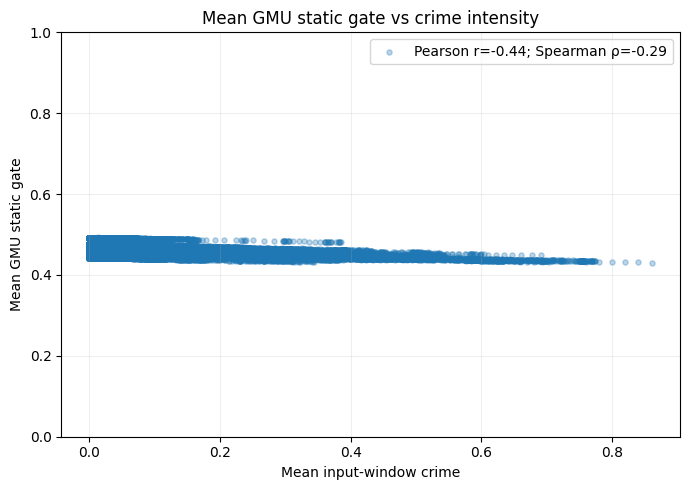

In [39]:
gmu_input_association = analyze_gate_vs_crime(
    results=results,
    gate_key="gate_static",
    crime_key="input_crime",
    gate_label="Mean GMU static gate",
    filename=(
        f"input_crime_vs_static_gate_{model_used}"
    ),
    output_path=output_folder,
)

### Easy explanation — first GMU gate-versus-crime plot

**Purpose.** This asks whether GMU changes modality balance as crime intensity changes.

Pearson correlation is **−0.438** and Spearman is **−0.291**. The negative direction means
that higher crime is associated with a lower static gate and therefore greater reliance on
dynamic crime history. Pearson being stronger than Spearman suggests the relationship is not
a uniformly strong monotonic ordering across all cases.

**Compared with M11.** M11 self gate has a much stronger Spearman relationship (**−0.659**),
and its neighbor gate moves in the opposite direction (**+0.348**). M11 therefore provides a
richer role-specific explanation.


# Interpretation notes

- A GMU gate near 1 favors the static latent representation; a gate near 0
  favors the dynamic latent representation.
- The gate is feature-wise, so its mean is only a compact summary.
- Gate values are learned mixing coefficients, not causal modality effects.
- The ablation experiment complements the gate analysis but does not replace
  separately trained static-only and dynamic-only baselines.
- For fair comparison with your message-level fusion model, use the same hidden dimension, optimizer policy, epochs, seeds, and evaluation split.
  Graph use must be reported as an architectural difference rather than silently matched.


# Complete GMU explainability and validation suite

This appendix makes the original GMU-only baseline analytically consistent with the
M11 notebook wherever the architectures permit a valid comparison. It does not alter
data preprocessing, dataset construction, training, or the existing analyses.

## Architectural comparability

| M11 analysis | Original GMU equivalent | Eligibility |
|---|---|---|
| Self and neighbor gate health | Single GMU gate health | Applicable with one role |
| Feature-wise gate specialization | GMU feature-wise specialization | Applicable |
| Gate–crime association | GMU gate–crime association | Applicable |
| Effective activation contribution | GMU effective activation contribution | Applicable |
| Self-versus-neighbor separation | None | **Not defined: GMU has one gate and no message passing** |
| Spatial/temporal stability | GMU node/time stability | Applicable |
| Gate–error relationship | GMU gate–error relationship | Applicable |
| Gate intervention | Single-gate interventions | Applicable |
| Input permutation importance | Static/dynamic input permutation | Applicable |
| Time-cluster bootstrap | Single-gate bootstrap | Applicable |
| Neighborhood-message explanation | None | **Not defined: GMU ignores `edge_index`** |

The existing exact-hop plot is retained only as contextual comparison between focal-node
predictions and graph neighbors. It must not be interpreted as learned neighborhood behavior.

### Split audit

The `InductiveWrapperDataset` calls are commented out in the supplied preprocessing.
Consequently, the executed configuration uses a chronological test period but includes the
same nodes in training and testing. It is temporally held out and node-transductive, not a
strict unseen-node inductive experiment. This note documents the current setup without
changing it.

## A. GMU embedding projection

t-SNE is included for parity with M11. It visualizes local structure in the fused GMU
representation from the first test window; it is not a quantitative performance measure.

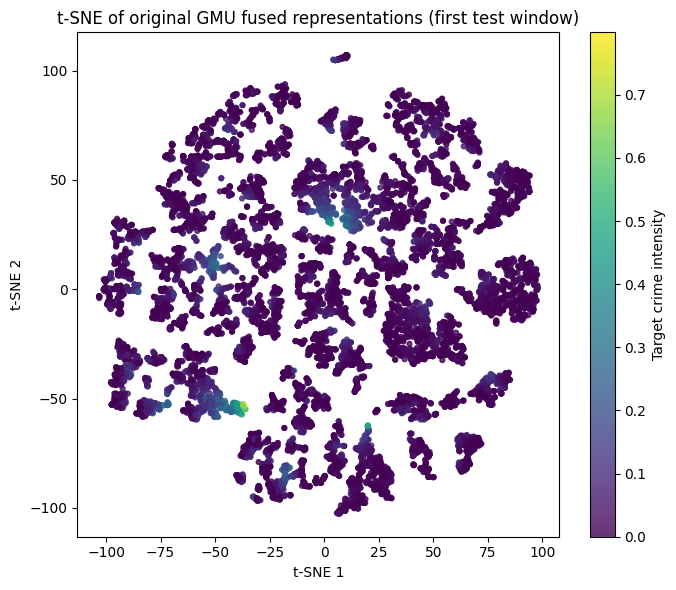

In [40]:
from sklearn.manifold import TSNE

embedding = test_results["embeddings_per_time"][0].numpy()
target_first_window = targets_per_t[0]

if embedding.shape[0] >= 3:
    perplexity = min(30, max(2, (embedding.shape[0] - 1) // 3))
    embedding_2d = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        random_state=seed,
    ).fit_transform(embedding)
    plt.figure(figsize=(7, 6))
    scatter = plt.scatter(
        embedding_2d[:, 0], embedding_2d[:, 1], c=target_first_window,
        cmap="viridis", s=12, alpha=0.8
    )
    plt.colorbar(scatter, label="Target crime intensity")
    plt.title("t-SNE of original GMU fused representations (first test window)")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.tight_layout()
    plt.savefig(os.path.join(output_folder, "gmu_embedding_tsne.png"), dpi=300, bbox_inches="tight")
    plt.show()
    pd.DataFrame({
        "tsne_1": embedding_2d[:, 0], "tsne_2": embedding_2d[:, 1],
        "target_crime": target_first_window,
    }).to_csv(os.path.join(output_folder, "gmu_embedding_tsne.csv"), index=False)
else:
    print("At least three nodes are required for t-SNE.")

### Easy explanation — t-SNE of GMU representations

**Purpose.** t-SNE projects GMU's 64-dimensional fused representation into two dimensions to
show local grouping. The colored points show target crime intensity.

The representation forms many local groups, so it has not collapsed. High-crime cases appear
in some localized areas, but most points are low crime.

**Compared with M11.** Both t-SNE plots show structured representations. Visual cluster shape
cannot determine which model is better because t-SNE can distort global distances. Prediction
metrics or quantitative embedding tests are needed; this analysis is a tie descriptively.


## B. Rich node-time GMU explainability collection

This cell collects the exact feature-wise GMU gate, both `tanh` modality candidates,
their gated activation magnitudes, predictions, errors, node IDs and time IDs. The same
definitions are then reused by all remaining analyses.

In [41]:
import contextlib
import math
import warnings

try:
    from scipy.stats import pearsonr, spearmanr
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False
    warnings.warn("SciPy is unavailable; p-values will be skipped.")


def _expand_gmu_metadata(value, n, fallback, device):
    if value is None:
        value = torch.as_tensor(fallback, device=device)
    value = value.reshape(-1)
    if value.numel() == 1 and n > 1:
        value = value.repeat(n)
    if value.numel() != n:
        raise ValueError(f"Metadata length {value.numel()} does not match node count {n}.")
    return value


@torch.no_grad()
def collect_rich_gmu_explainability(model, loader, device):
    model.eval()
    frames, gate_vectors = [], []
    for step, data in enumerate(loader):
        data = data.to(device)
        prediction, embedding, details = model(
            data.x_static, data.x_dynamic, data.edge_index, return_details=True
        )
        prediction = prediction.reshape(-1)
        target = data.y.float().view_as(prediction)
        n = prediction.numel()
        node_ids = _expand_gmu_metadata(
            getattr(data, "node_ids", None), n, torch.arange(n, device=device), device
        )
        time_ids = _expand_gmu_metadata(getattr(data, "time_id", None), n, step, device)

        gate = details["gate"]
        h_static = details["h_static"]
        h_dynamic = details["h_dynamic"]
        static_component = gate * h_static
        dynamic_component = (1.0 - gate) * h_dynamic
        static_mag = torch.linalg.vector_norm(static_component, dim=1)
        dynamic_mag = torch.linalg.vector_norm(dynamic_component, dim=1)
        static_prop = static_mag / (static_mag + dynamic_mag + 1e-12)

        frames.append(pd.DataFrame({
            "node_id": node_ids.cpu().numpy(),
            "time_id": time_ids.cpu().numpy(),
            "input_crime": data.x_dynamic.mean(dim=1).cpu().numpy(),
            "target_crime": target.cpu().numpy(),
            "prediction": prediction.cpu().numpy(),
            "residual": (target - prediction).cpu().numpy(),
            "absolute_error": (target - prediction).abs().cpu().numpy(),
            "gmu_static_gate": gate.mean(dim=1).cpu().numpy(),
            "gmu_dynamic_gate": (1.0 - gate).mean(dim=1).cpu().numpy(),
            "static_activation": static_mag.cpu().numpy(),
            "dynamic_activation": dynamic_mag.cpu().numpy(),
            "static_activation_proportion": static_prop.cpu().numpy(),
            "dynamic_activation_proportion": (1.0-static_prop).cpu().numpy(),
        }))
        gate_vectors.append(gate.cpu())
    return pd.concat(frames, ignore_index=True), torch.cat(gate_vectors).numpy()


gmu_explain_frame, gmu_gate_vectors = collect_rich_gmu_explainability(
    model, test_loader, device
)
print("Explainability cases:", len(gmu_explain_frame))
print("GMU gate vector shape:", gmu_gate_vectors.shape)
display(gmu_explain_frame.head())
gmu_explain_frame.to_csv(os.path.join(output_folder, "gmu_rich_explainability_cases.csv"), index=False)

Explainability cases: 570960
GMU gate vector shape: (570960, 64)


,node_id,time_id,input_crime,target_crime,prediction,residual,absolute_error,gmu_static_gate,gmu_dynamic_gate,static_activation,dynamic_activation,static_activation_proportion,dynamic_activation_proportion
0,0,100,0.126909,0.136371,0.108100,0.028271,0.028271,0.459069,0.540931,1.007478,0.252320,0.799714,0.200286
1,1,100,0.109170,0.097192,0.099246,-0.002054,0.002054,0.467030,0.532970,0.951987,0.214041,0.816436,0.183564
2,2,100,0.161374,0.125887,0.132608,-0.006721,0.006721,0.458559,0.541441,0.968298,0.314020,0.755115,0.244885
3,3,100,0.096176,0.097884,0.085115,0.012769,0.012769,0.460948,0.539052,0.901365,0.195709,0.821608,0.178392
4,4,100,0.014133,0.041428,0.042898,-0.001469,0.001469,0.463360,0.536640,0.962005,0.083344,0.920272,0.079728


### Easy explanation — rich GMU explainability table

Each row contains one node-time case with input crime, target, prediction, error, the
64-dimensional gate summarized as a mean, and effective activation magnitudes. There are
**570,960 cases** and 64 gate dimensions.

The first rows already show an important distinction: raw static gates are around 0.46, but
effective static activation proportions are approximately 0.76–0.92. This means candidate
representation magnitude strongly changes the actual mixture.

**Compared with M11.** M11 collects separate self and neighbor components and has balanced
effective contributions after LayerNorm. Its table supports more detailed role analysis.


## C. Gate health: variation, entropy and saturation

A global mean near 0.5 is not gate collapse. Collapse is better assessed through
feature-wise variance, case-level variance, entropy, saturation, intervention evidence,
and repeatability across seeds.

,role,global_mean,global_std,case_mean_std,q05,median,q95,minimum,maximum,mean_entropy_0_to_1,fraction_below_0.10,fraction_above_0.90,fraction_near_balanced_0.45_0.55
0,single_GMU_gate,0.4644,0.0641,0.0072,0.3575,0.4663,0.5652,0.2306,0.7137,0.9843,0.0,0.0,0.5037


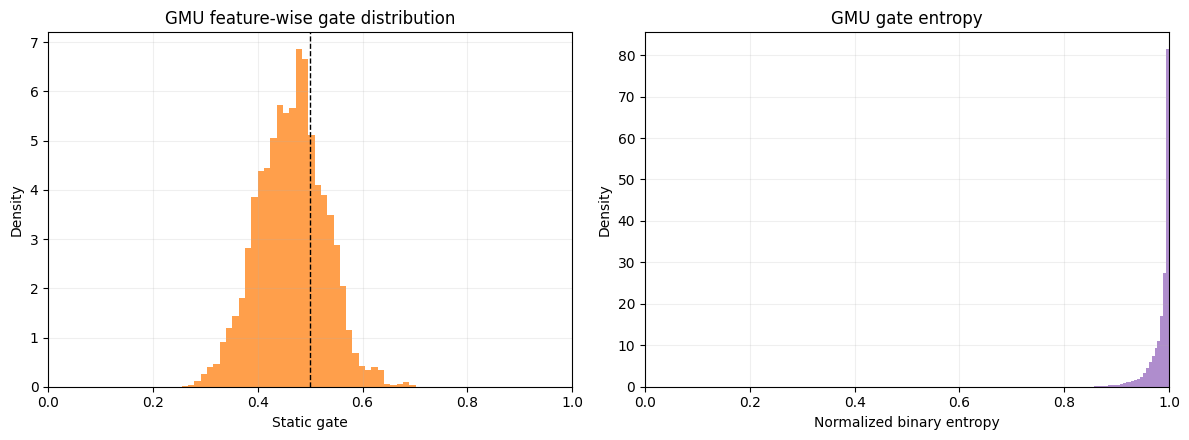

In [42]:
def binary_gate_entropy(gates, eps=1e-8):
    g = np.clip(np.asarray(gates), eps, 1.0-eps)
    return -(g*np.log(g) + (1.0-g)*np.log(1.0-g)) / np.log(2.0)


flat_gate = gmu_gate_vectors.reshape(-1)
case_gate = gmu_gate_vectors.mean(axis=1)
gmu_gate_health = pd.DataFrame([{
    "role": "single_GMU_gate",
    "global_mean": flat_gate.mean(),
    "global_std": flat_gate.std(),
    "case_mean_std": case_gate.std(),
    "q05": np.quantile(flat_gate, 0.05),
    "median": np.median(flat_gate),
    "q95": np.quantile(flat_gate, 0.95),
    "minimum": flat_gate.min(),
    "maximum": flat_gate.max(),
    "mean_entropy_0_to_1": binary_gate_entropy(flat_gate).mean(),
    "fraction_below_0.10": np.mean(flat_gate < 0.10),
    "fraction_above_0.90": np.mean(flat_gate > 0.90),
    "fraction_near_balanced_0.45_0.55": np.mean((flat_gate >= 0.45) & (flat_gate <= 0.55)),
}])
display(gmu_gate_health.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(flat_gate, bins=40, density=True, alpha=0.75, color="tab:orange")
axes[0].axvline(0.5, color="black", linestyle="--", linewidth=1)
axes[0].set(title="GMU feature-wise gate distribution", xlabel="Static gate", ylabel="Density", xlim=(0, 1))
axes[1].hist(binary_gate_entropy(flat_gate), bins=40, density=True, alpha=0.75, color="tab:purple")
axes[1].set(title="GMU gate entropy", xlabel="Normalized binary entropy", ylabel="Density", xlim=(0, 1))
for ax in axes:
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_professional_gate_health.png"), dpi=300, bbox_inches="tight")
plt.show()
gmu_gate_health.to_csv(os.path.join(output_folder, "gmu_professional_gate_health.csv"), index=False)

### Easy explanation — GMU gate health

**Purpose.** This checks whether gate values vary, saturate, or remain close to 0.5.

GMU has mean 0.464, standard deviation **0.064**, and very high entropy **0.984**. No values
are below 0.1 or above 0.9, and about 50% lie between 0.45 and 0.55. Thus GMU uses soft,
mostly balanced feature-wise gates with limited specialization. It has not collapsed to one
constant, but it also makes few decisive selections.

**Compared with M11.** M11 self/neighbor standard deviations are 0.285/0.202 with lower
entropies 0.719/0.872 and many near-extreme dimensions. M11 is clearly better for prominent
feature-wise specialization. GMU's softness is not automatically bad—it achieves better
forecasting—but it offers a weaker gate-selection explanation.


## D. Feature-wise GMU specialization

GMU has an $N\times H$ gate. This analysis checks whether averaging across the 64 latent
dimensions hides opposing static- and dynamic-preferring components.

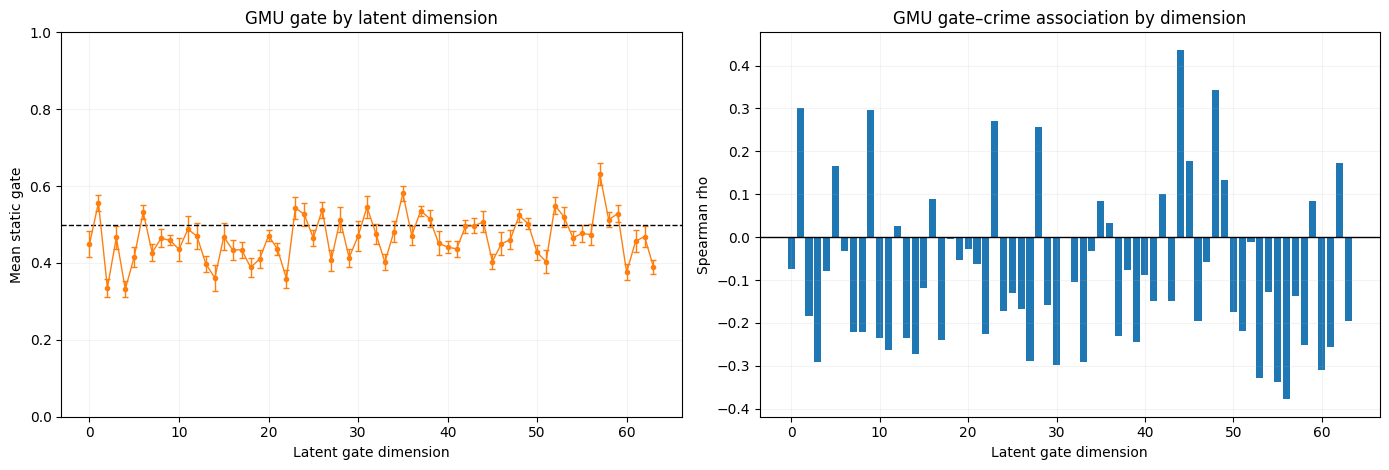

,dimension,mean_gate,std_gate,crime_spearman_rho,crime_spearman_p
44,44,0.506909,0.027002,0.436698,0.0
56,56,0.473689,0.026666,-0.377952,0.0
48,48,0.523644,0.016231,0.343383,0.0
55,55,0.476934,0.022917,-0.336653,0.0
53,53,0.520213,0.025467,-0.329442,0.0
60,60,0.375846,0.020744,-0.309258,0.0
1,1,0.556302,0.021807,0.300966,0.0
30,30,0.469960,0.038968,-0.297132,0.0
9,9,0.458660,0.013106,0.296777,0.0
33,33,0.401986,0.020568,-0.291916,0.0


In [43]:
def safe_correlations(x, matrix, method="spearman"):
    x = np.asarray(x)
    values, pvalues = [], []
    for k in range(matrix.shape[1]):
        y = matrix[:, k]
        if np.std(x) == 0 or np.std(y) == 0:
            values.append(np.nan); pvalues.append(np.nan)
        elif SCIPY_AVAILABLE:
            result = spearmanr(x, y) if method == "spearman" else pearsonr(x, y)
            values.append(float(result[0])); pvalues.append(float(result[1]))
        else:
            values.append(float(np.corrcoef(x, y)[0, 1])); pvalues.append(np.nan)
    return np.asarray(values), np.asarray(pvalues)


crime_values = gmu_explain_frame["input_crime"].to_numpy()
gate_means = gmu_gate_vectors.mean(axis=0)
gate_stds = gmu_gate_vectors.std(axis=0)
gate_rho, gate_p = safe_correlations(crime_values, gmu_gate_vectors, "spearman")
dims = np.arange(gmu_gate_vectors.shape[1])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].errorbar(dims, gate_means, yerr=gate_stds, marker="o", markersize=3,
                 linewidth=1, capsize=2, color="tab:orange")
axes[0].axhline(0.5, color="black", linestyle="--", linewidth=1)
axes[0].set(title="GMU gate by latent dimension", xlabel="Latent gate dimension",
            ylabel="Mean static gate", ylim=(0, 1))
axes[1].bar(dims, gate_rho, color="tab:blue")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set(title="GMU gate–crime association by dimension", xlabel="Latent gate dimension",
            ylabel="Spearman rho")
for ax in axes: ax.grid(alpha=0.15)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_featurewise_gate_specialization.png"), dpi=300, bbox_inches="tight")
plt.show()

gmu_featurewise_gate_stats = pd.DataFrame({
    "dimension": dims, "mean_gate": gate_means, "std_gate": gate_stds,
    "crime_spearman_rho": gate_rho, "crime_spearman_p": gate_p,
})
display(gmu_featurewise_gate_stats.reindex(
    gmu_featurewise_gate_stats.crime_spearman_rho.abs().sort_values(ascending=False).index
).head(10))
gmu_featurewise_gate_stats.to_csv(os.path.join(output_folder, "gmu_featurewise_gate_stats.csv"), index=False)

### Easy explanation — feature-wise GMU specialization

**Purpose.** This examines each of GMU's 64 latent gate dimensions separately. Positive
crime correlation means a dimension becomes more static as crime rises; negative means more
dynamic.

The strongest absolute correlation is about **0.437** (dimension 44). Most dimension means
remain near 0.5 and their variations are modest. Some dimensions respond differently to
crime, so averaging does hide structure, but specialization is moderate.

**Compared with M11.** M11 has several absolute correlations around 0.8–0.96 and dimensions
with mean gates near 0 or 1. M11 is substantially stronger for feature-wise conditional
selection. Latent dimensions in either model are not named socioeconomic features.


## E. GMU gate association with input and future crime

Pearson measures linear association and Spearman measures monotonic association. Statistics
use all original node-time cases; quantile bins are used only to make the plot readable.

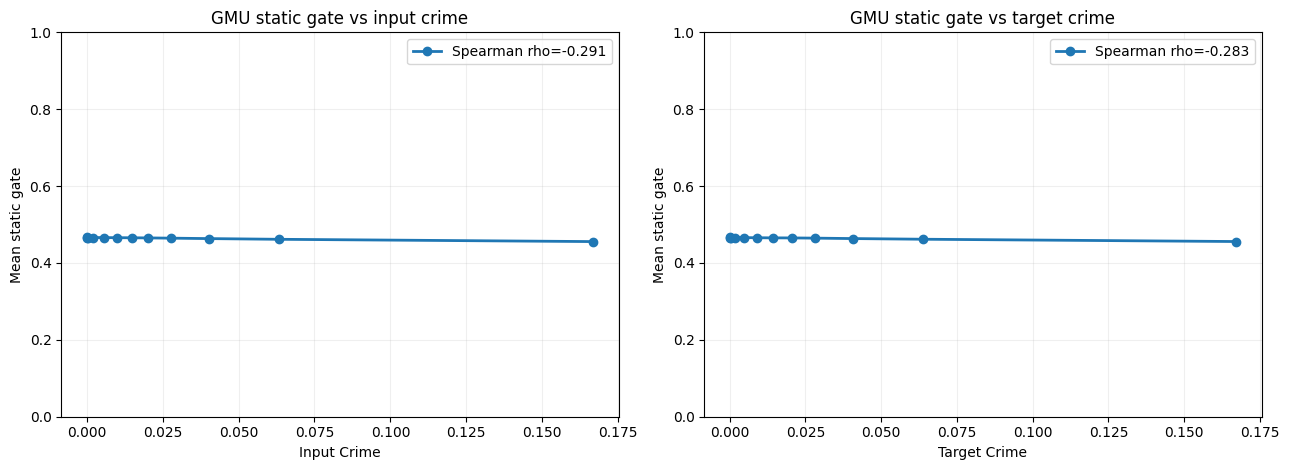

,role,crime_variable,pearson_r,pearson_p,spearman_rho,spearman_p
0,GMU,input_crime,-0.43825,0.0,-0.29060,0.0
1,GMU,target_crime,-0.43100,0.0,-0.28289,0.0


In [44]:
def association_stats(x, y):
    x, y = np.asarray(x), np.asarray(y)
    valid = np.isfinite(x) & np.isfinite(y)
    x, y = x[valid], y[valid]
    if len(x) < 3 or np.std(x) == 0 or np.std(y) == 0:
        return {"pearson_r": np.nan, "pearson_p": np.nan,
                "spearman_rho": np.nan, "spearman_p": np.nan}
    if SCIPY_AVAILABLE:
        pr, sr = pearsonr(x, y), spearmanr(x, y)
        return {"pearson_r": float(pr[0]), "pearson_p": float(pr[1]),
                "spearman_rho": float(sr[0]), "spearman_p": float(sr[1])}
    return {"pearson_r": float(np.corrcoef(x, y)[0, 1]), "pearson_p": np.nan,
            "spearman_rho": np.nan, "spearman_p": np.nan}


def binned_summary(frame, x_col, y_col, bins=12):
    work = frame[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna().copy()
    work["bin"] = pd.qcut(work[x_col], q=bins, duplicates="drop")
    out = work.groupby("bin", observed=True).agg(
        mean_x=(x_col, "mean"), mean_y=(y_col, "mean"),
        std_y=(y_col, "std"), count=(y_col, "size")
    ).reset_index(drop=True)
    out["ci95"] = 1.96*out["std_y"] / np.sqrt(out["count"].clip(lower=1))
    return out


gmu_association_rows = []
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, x_col in zip(axes, ["input_crime", "target_crime"]):
    stats = association_stats(gmu_explain_frame[x_col], gmu_explain_frame["gmu_static_gate"])
    gmu_association_rows.append({"role": "GMU", "crime_variable": x_col, **stats})
    summary = binned_summary(gmu_explain_frame, x_col, "gmu_static_gate", bins=12)
    ax.plot(summary["mean_x"], summary["mean_y"], marker="o", linewidth=2)
    ax.fill_between(summary["mean_x"], summary["mean_y"]-summary["ci95"],
                    summary["mean_y"]+summary["ci95"], alpha=0.2)
    ax.set(title=f"GMU static gate vs {x_col.replace('_', ' ')}",
           xlabel=x_col.replace("_", " ").title(), ylabel="Mean static gate", ylim=(0, 1))
    ax.legend([f"Spearman rho={stats['spearman_rho']:.3f}"])
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_gate_crime_associations.png"), dpi=300, bbox_inches="tight")
plt.show()
gmu_gate_crime_associations = pd.DataFrame(gmu_association_rows)
display(gmu_gate_crime_associations.round(5))
gmu_gate_crime_associations.to_csv(os.path.join(output_folder, "gmu_gate_crime_associations.csv"), index=False)

### Easy explanation — GMU gate versus input and target crime

GMU's Spearman correlations are **−0.291** for input crime and **−0.283** for future target
crime. Higher crime is therefore associated with a modest shift toward dynamic information.

**Compared with M11.** M11 self correlations are much stronger (about −0.659), while its
neighbor correlations are positive (about +0.348 to +0.381). M11 wins this analysis because
it reveals distinct self and spatial-context roles that a single GMU gate cannot represent.
These are observational associations, not causal effects.


## F. Effective gated activation contribution

Raw gates do not include the magnitude of `tanh` candidate representations. The effective
static proportion below compares $\|z\odot h_s\|_2$ with
$\|(1-z)\odot h_d\|_2$. It is a representation-magnitude diagnostic, not causal importance.

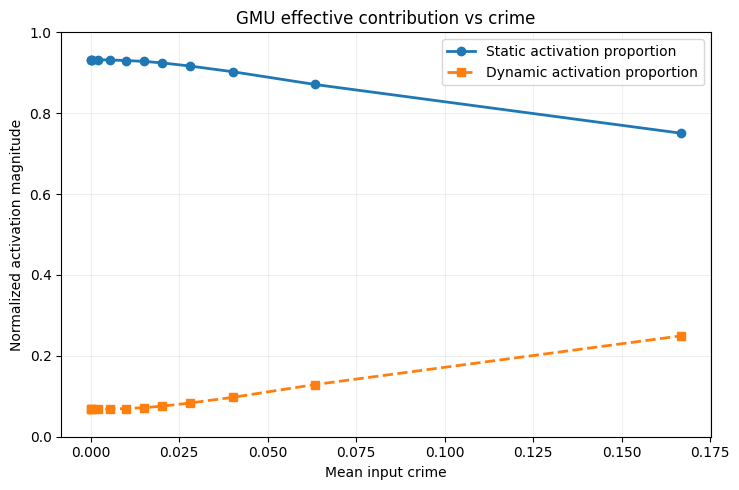

,role,mean_raw_static_gate,mean_effective_static_proportion,mean_effective_dynamic_proportion,gate_vs_effective_pearson
0,single_GMU_gate,0.4644,0.907,0.093,0.2462


In [45]:
summary = binned_summary(gmu_explain_frame, "input_crime", "static_activation_proportion", bins=12)
plt.figure(figsize=(7.5, 5))
plt.plot(summary["mean_x"], summary["mean_y"], marker="o", linewidth=2,
         label="Static activation proportion")
plt.plot(summary["mean_x"], 1.0-summary["mean_y"], marker="s", linestyle="--",
         linewidth=2, label="Dynamic activation proportion")
plt.fill_between(summary["mean_x"], summary["mean_y"]-summary["ci95"],
                 summary["mean_y"]+summary["ci95"], alpha=0.15)
plt.xlabel("Mean input crime")
plt.ylabel("Normalized activation magnitude")
plt.ylim(0, 1)
plt.title("GMU effective contribution vs crime")
plt.legend(); plt.grid(alpha=0.2); plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_effective_activation_contribution.png"), dpi=300, bbox_inches="tight")
plt.show()

gmu_effective_contribution = pd.DataFrame([{
    "role": "single_GMU_gate",
    "mean_raw_static_gate": gmu_explain_frame["gmu_static_gate"].mean(),
    "mean_effective_static_proportion": gmu_explain_frame["static_activation_proportion"].mean(),
    "mean_effective_dynamic_proportion": gmu_explain_frame["dynamic_activation_proportion"].mean(),
    "gate_vs_effective_pearson": association_stats(
        gmu_explain_frame["gmu_static_gate"], gmu_explain_frame["static_activation_proportion"]
    )["pearson_r"],
}])
display(gmu_effective_contribution.round(4))
gmu_effective_contribution.to_csv(os.path.join(output_folder, "gmu_effective_contribution.csv"), index=False)

### Easy explanation — effective activation contribution

**Purpose.** Raw gates are only multipliers. This analysis also measures the sizes of the
static and dynamic `tanh` candidate vectors after gating.

Although the raw static gate is only **0.464**, effective activation is **90.7% static and
9.3% dynamic**. Gate and effective static proportion correlate only 0.246. GMU's static
candidate vectors are therefore much larger than its dynamic candidate vectors, allowing
static activation magnitude to dominate despite a slightly dynamic-favoring gate.

**Compared with M11.** M11 has balanced effective contributions: approximately 52.8% static
for self and 56.2% for neighbors. M11 is decisively better for interpreting its raw gate as
modality balance. GMU's 90.7% value must not be called predictive importance—the ablation and
gradients show dynamic inputs are actually crucial.


## G. Self-versus-neighbor separation — not applicable

Original GMU has one pre-regression gate per node-time case. It has neither a self-update
gate nor a neighbor-message gate, and it does not use `edge_index`. Creating a second gate
only for this plot would change the baseline into a different architecture. Therefore this
M11-specific analysis is deliberately omitted and recorded as **not defined for GMU**.

### Easy explanation — why self-versus-neighbor analysis is unavailable

Original GMU has one node-level fusion gate and no graph message passing. It cannot separate
a node's own modality balance from the modality balance used in neighbor messages.

**Compared with M11.** This is a unique advantage of M11. M11 shows a negative correlation
of −0.629 between self and neighbor gates and different responses to crime. If your research
contribution is fusion *during message passing*, M11 is the more appropriate model even
though GMU has lower forecast error in this single run.


## H. Spatial and temporal stability of the single GMU gate

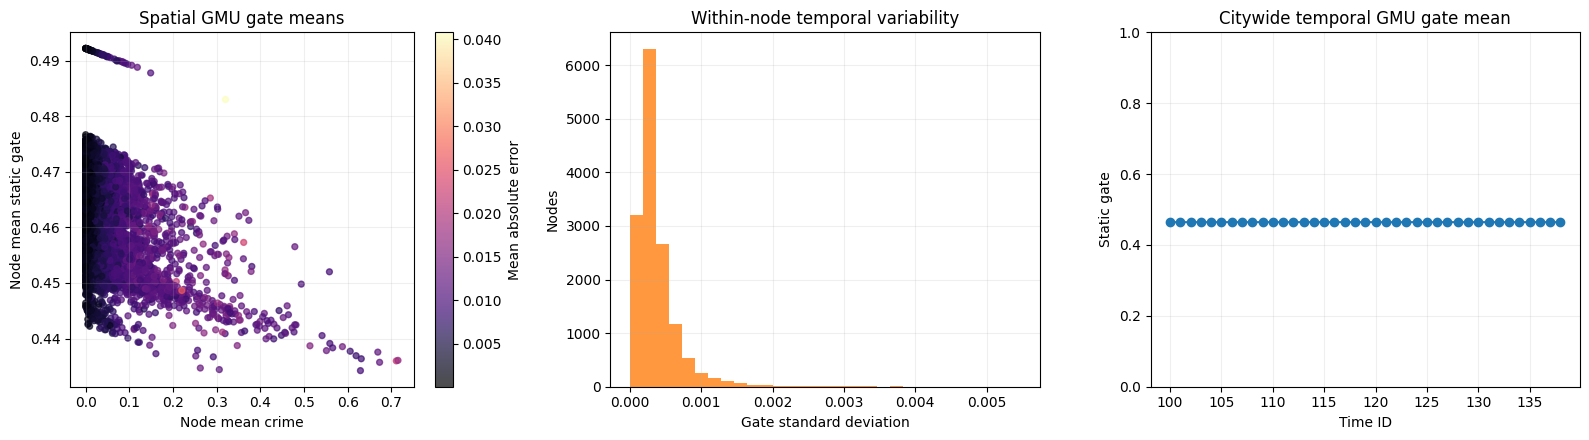

,node_id,gate_mean,gate_std,mean_crime,mean_absolute_error
13759,13759,0.457306,0.005471,0.361775,0.023106
8149,8149,0.451636,0.005451,0.321197,0.020440
10708,10708,0.445116,0.005209,0.310790,0.012017
5155,5155,0.443748,0.005186,0.279655,0.012090
2538,2538,0.463637,0.004922,0.227495,0.017196
11888,11888,0.443088,0.004666,0.399450,0.013736
1423,1423,0.465301,0.004414,0.285412,0.018856
3852,3852,0.459073,0.004329,0.219688,0.009994
6896,6896,0.444153,0.004191,0.350025,0.016216
12749,12749,0.448546,0.004149,0.191998,0.010524


In [46]:
gmu_node_stability = gmu_explain_frame.groupby("node_id").agg(
    gate_mean=("gmu_static_gate", "mean"), gate_std=("gmu_static_gate", "std"),
    mean_crime=("input_crime", "mean"), mean_absolute_error=("absolute_error", "mean"),
).reset_index()
gmu_time_stability = gmu_explain_frame.groupby("time_id").agg(
    gate_mean=("gmu_static_gate", "mean"), gate_std=("gmu_static_gate", "std"),
    mean_crime=("input_crime", "mean"),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sc = axes[0].scatter(gmu_node_stability["mean_crime"], gmu_node_stability["gate_mean"],
                     c=gmu_node_stability["mean_absolute_error"], cmap="magma", s=18, alpha=0.7)
fig.colorbar(sc, ax=axes[0], label="Mean absolute error")
axes[0].set(title="Spatial GMU gate means", xlabel="Node mean crime", ylabel="Node mean static gate")
axes[1].hist(gmu_node_stability["gate_std"].dropna(), bins=30, color="tab:orange", alpha=0.8)
axes[1].set(title="Within-node temporal variability", xlabel="Gate standard deviation", ylabel="Nodes")
axes[2].plot(gmu_time_stability["time_id"], gmu_time_stability["gate_mean"], marker="o")
axes[2].set(title="Citywide temporal GMU gate mean", xlabel="Time ID", ylabel="Static gate", ylim=(0, 1))
for ax in axes: ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_spatial_temporal_gate_stability.png"), dpi=300, bbox_inches="tight")
plt.show()
display(gmu_node_stability.sort_values("gate_std", ascending=False).head(10))
gmu_node_stability.to_csv(os.path.join(output_folder, "gmu_node_gate_stability.csv"), index=False)
gmu_time_stability.to_csv(os.path.join(output_folder, "gmu_time_gate_stability.csv"), index=False)

### Easy explanation — spatial and temporal GMU stability

**Purpose.** This asks whether GMU gate behavior changes across nodes and over time or is
mainly constant.

Node means vary modestly with crime. The most variable nodes have temporal gate standard
deviations only around **0.0055**, and the citywide temporal mean is nearly flat. GMU is very
stable but only mildly adaptive at the case-mean level.

**Compared with M11.** M11 self gates reach within-node standard deviations around 0.018 and
show greater conditional variation. GMU is better for stability/simplicity; M11 is better for
demonstrating adaptive modality selection.


## I. GMU gate relationship with prediction error

This identifies associations between modality balance and difficult cases. It does not show
that changing the gate would necessarily reduce an error; the intervention test addresses
functional faithfulness more directly.

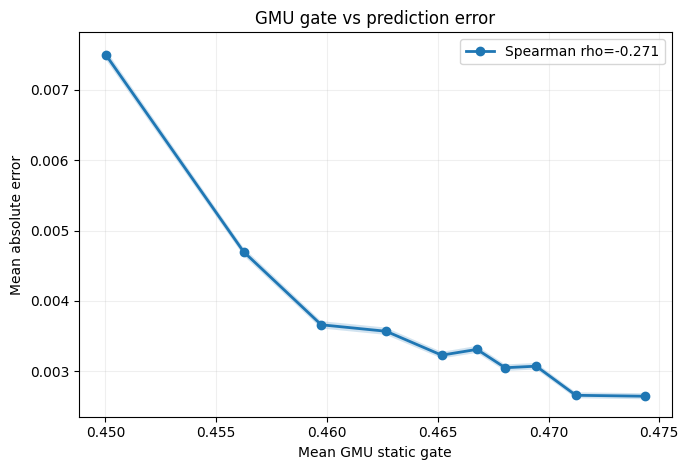

,role,pearson_r,pearson_p,spearman_rho,spearman_p
0,GMU,-0.19791,0.0,-0.27135,0.0


In [47]:
gmu_error_stats = association_stats(
    gmu_explain_frame["gmu_static_gate"], gmu_explain_frame["absolute_error"]
)
summary = binned_summary(gmu_explain_frame, "gmu_static_gate", "absolute_error", bins=10)
plt.figure(figsize=(7, 4.8))
plt.plot(summary["mean_x"], summary["mean_y"], marker="o", linewidth=2)
plt.fill_between(summary["mean_x"], summary["mean_y"]-summary["ci95"],
                 summary["mean_y"]+summary["ci95"], alpha=0.2)
plt.xlabel("Mean GMU static gate"); plt.ylabel("Mean absolute error")
plt.title("GMU gate vs prediction error")
plt.legend([f"Spearman rho={gmu_error_stats['spearman_rho']:.3f}"])
plt.grid(alpha=0.2); plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_gate_error_relationship.png"), dpi=300, bbox_inches="tight")
plt.show()
gmu_gate_error_association = pd.DataFrame([{"role": "GMU", **gmu_error_stats}])
display(gmu_gate_error_association.round(5))
gmu_gate_error_association.to_csv(os.path.join(output_folder, "gmu_gate_error_association.csv"), index=False)

### Easy explanation — GMU gate versus prediction error

Spearman correlation is **−0.271**. Higher static-gate cases tend to have lower absolute
errors. This does not prove that increasing the gate would improve prediction; crime level
may influence both error and gate value.

**Compared with M11.** M11 self correlation is somewhat stronger (−0.346), while its neighbor
relationship is nearly zero. Both models show that the self/node-level balance is associated
with difficulty. M11 provides the richer diagnosis, but neither result is causal.


## J. Single-gate intervention faithfulness

All trained weights remain fixed while the GMU gate logits are replaced. Fixed probabilities
are strong off-manifold interventions; shuffled logits are often the more credible test
because they preserve the learned logit distribution while breaking assignment to cases.

,intervention,MSE,RMSE,MAE,delta_MSE_vs_learned,relative_MSE_change_percent
0,Learned gate,0.00005,0.00736,0.00374,0.00000,0.00000
1,Balanced gate (0.5),0.00035,0.01862,0.01336,0.00029,540.26416
2,Static-heavy gate (0.95),0.00293,0.05416,0.02763,0.00288,5318.58849
3,Dynamic-heavy gate (0.05),0.00146,0.03822,0.02067,0.00141,2599.08275
4,Shuffled learned gate logits,0.00032,0.01780,0.01312,0.00026,485.46615


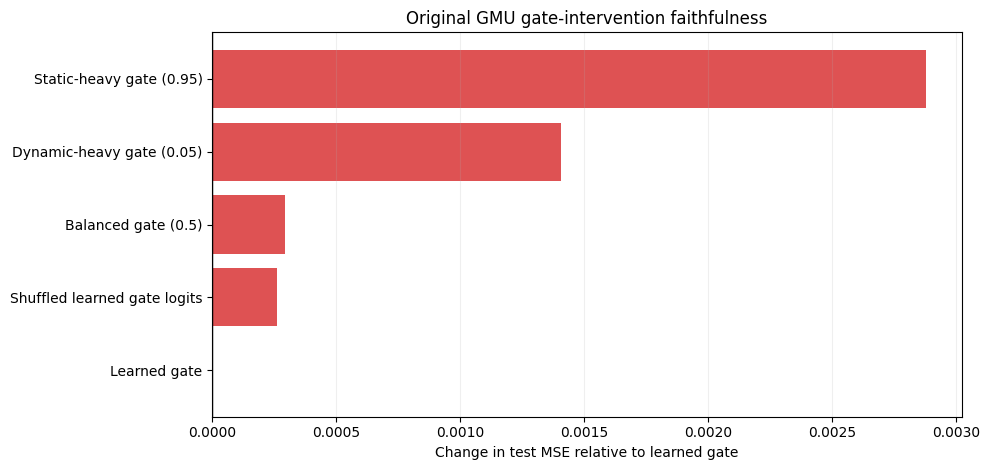

In [48]:
def _constant_logit_hook(probability):
    p = float(np.clip(probability, 1e-4, 1.0-1e-4))
    logit = math.log(p/(1.0-p))
    def hook(module, inputs, output):
        return torch.full_like(output, logit)
    return hook


def _shuffle_logit_hook(random_seed):
    counter = {"value": 0}
    def hook(module, inputs, output):
        generator = torch.Generator(device=output.device)
        generator.manual_seed(random_seed + counter["value"])
        counter["value"] += 1
        flat = output.reshape(-1)
        permutation = torch.randperm(flat.numel(), generator=generator, device=output.device)
        return flat[permutation].reshape_as(output)
    return hook


@contextlib.contextmanager
def gmu_gate_intervention(model, probability=None, shuffle=False, random_seed=42):
    handle = None
    try:
        if shuffle:
            handle = model.gmu.gate_layer.register_forward_hook(_shuffle_logit_hook(random_seed))
        elif probability is not None:
            handle = model.gmu.gate_layer.register_forward_hook(_constant_logit_hook(probability))
        yield
    finally:
        if handle is not None:
            handle.remove()


def evaluate_current_gmu(model, loader, device):
    model.eval(); pred_all, target_all = [], []
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            prediction, _ = model(data.x_static, data.x_dynamic, data.edge_index)
            target = data.y.float().view_as(prediction)
            pred_all.append(prediction.cpu()); target_all.append(target.cpu())
    prediction = torch.cat(pred_all).numpy(); target = torch.cat(target_all).numpy()
    error = prediction-target; mse = float(np.mean(error**2))
    return {"MSE": mse, "RMSE": float(np.sqrt(mse)), "MAE": float(np.mean(np.abs(error)))}


gmu_intervention_specs = [
    ("Learned gate", None, False),
    ("Balanced gate (0.5)", 0.5, False),
    ("Static-heavy gate (0.95)", 0.95, False),
    ("Dynamic-heavy gate (0.05)", 0.05, False),
    ("Shuffled learned gate logits", None, True),
]
gmu_intervention_rows = []
for label, probability, shuffle in gmu_intervention_specs:
    with gmu_gate_intervention(model, probability, shuffle, seed):
        row = evaluate_current_gmu(model, test_loader, device)
    gmu_intervention_rows.append({"intervention": label, **row})
gmu_gate_interventions = pd.DataFrame(gmu_intervention_rows)
gmu_baseline_mse = gmu_gate_interventions.loc[
    gmu_gate_interventions.intervention == "Learned gate", "MSE"
].iloc[0]
gmu_gate_interventions["delta_MSE_vs_learned"] = gmu_gate_interventions["MSE"]-gmu_baseline_mse
gmu_gate_interventions["relative_MSE_change_percent"] = (
    100*gmu_gate_interventions["delta_MSE_vs_learned"]/(gmu_baseline_mse+1e-12)
)
display(gmu_gate_interventions.round(5))

plot_df = gmu_gate_interventions.sort_values("delta_MSE_vs_learned")
plt.figure(figsize=(10, 4.8))
plt.barh(plot_df["intervention"], plot_df["delta_MSE_vs_learned"],
         color=["tab:green" if x <= 0 else "tab:red" for x in plot_df["delta_MSE_vs_learned"]], alpha=0.8)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Change in test MSE relative to learned gate")
plt.title("Original GMU gate-intervention faithfulness")
plt.grid(axis="x", alpha=0.2); plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_gate_intervention_faithfulness.png"), dpi=300, bbox_inches="tight")
plt.show()
gmu_gate_interventions.to_csv(os.path.join(output_folder, "gmu_gate_interventions.csv"), index=False)

### Easy explanation — GMU gate-intervention faithfulness

**Purpose.** Model weights are frozen and only gate outputs are changed. Worsening prediction
shows that learned gate assignment matters.

Learned GMU MSE is 0.000054. Balanced gates produce 0.00035, and shuffled learned logits
produce 0.00032—about a **485% relative increase**. This is credible evidence that learned
gate placement matters. Extreme gates cause still larger errors but are strongly off-manifold.

**Compared with M11.** M11's shuffled-gate MSE increase is 0.003535, about **5,463%** relative
to its baseline. M11 is much more dependent on precise gate routing and wins the faithfulness
strength comparison. GMU remains convincingly faithful but uses a softer, less critical gate.


## K. Model-agnostic input permutation importance

This returns from latent gates to named socioeconomic features and temporal lags. An increase
in MSE after node-wise permutation indicates reliance by the frozen model. Correlated inputs
can share or redistribute importance, so rankings are not causal effects.

,modality,feature,baseline_MSE,permuted_MSE_mean,permuted_MSE_std,delta_MSE
15,dynamic,crime_lag_1,0.000054,0.003575,1.899255e-06,3.520711e-03
14,dynamic,crime_lag_2,0.000054,0.000265,1.836247e-07,2.110666e-04
13,dynamic,crime_lag_3,0.000054,0.000075,5.065711e-08,2.076359e-05
12,dynamic,crime_lag_4,0.000054,0.000063,6.033047e-09,8.928227e-06
5,static,18_a_65_anos_taxa,0.000054,0.000060,1.289327e-08,6.306657e-06
0,static,Renda_media_por_domicilio,0.000054,0.000060,5.424549e-08,5.591422e-06
6,static,maiores_de_65_anos_taxa,0.000054,0.000058,4.300789e-08,4.041845e-06
4,static,menores_de_18_anos_taxa,0.000054,0.000058,3.195150e-08,3.911948e-06
1,static,Renda_media_responsaveis,0.000054,0.000057,4.336187e-08,3.112050e-06
11,dynamic,crime_lag_5,0.000054,0.000057,2.373245e-08,2.412607e-06


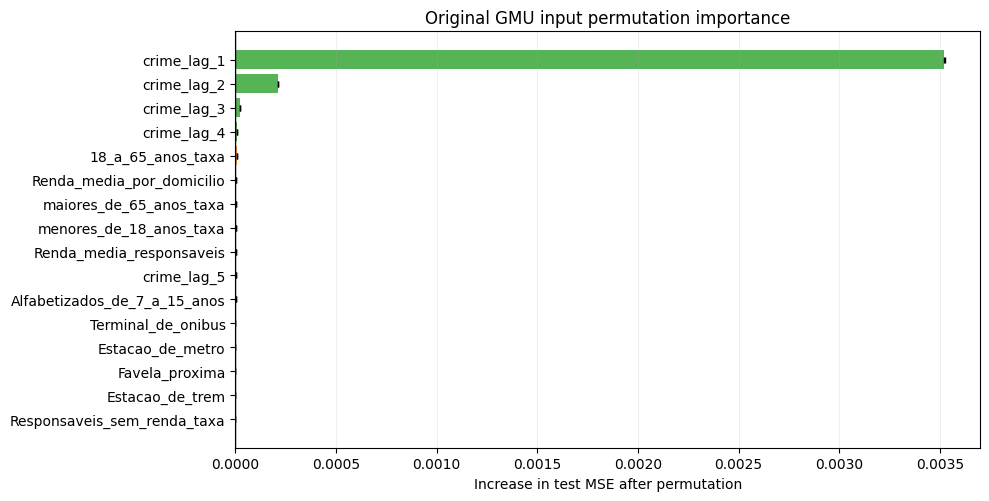

In [49]:
@torch.no_grad()
def gmu_permutation_importance(model, loader, device, static_names=None, repeats=3, random_seed=42):
    model.eval()
    baseline = evaluate_current_gmu(model, loader, device)["MSE"]
    sample = next(iter(loader))
    static_dim, dynamic_dim = sample.x_static.shape[1], sample.x_dynamic.shape[1]
    if static_names is None or len(static_names) != static_dim:
        static_names = [f"static_{i}" for i in range(static_dim)]
    dynamic_names = [f"crime_lag_{dynamic_dim-i}" for i in range(dynamic_dim)]
    rows = []
    for modality, dim, names in [("static", static_dim, static_names),
                                 ("dynamic", dynamic_dim, dynamic_names)]:
        for feature_index in range(dim):
            repeated_mse = []
            for repeat in range(repeats):
                pred_all, target_all = [], []
                generator = torch.Generator(device=device)
                generator.manual_seed(random_seed + 1000*feature_index + 17*repeat +
                                      (0 if modality == "static" else 100000))
                for data in loader:
                    data = data.to(device)
                    xs, xd = data.x_static.clone(), data.x_dynamic.clone()
                    permutation = torch.randperm(xs.shape[0], generator=generator, device=device)
                    if modality == "static": xs[:, feature_index] = xs[permutation, feature_index]
                    else: xd[:, feature_index] = xd[permutation, feature_index]
                    prediction, _ = model(xs, xd, data.edge_index)
                    pred_all.append(prediction.cpu()); target_all.append(data.y.float().view_as(prediction).cpu())
                prediction = torch.cat(pred_all).numpy(); target = torch.cat(target_all).numpy()
                repeated_mse.append(float(np.mean((prediction-target)**2)))
            rows.append({
                "modality": modality, "feature": names[feature_index], "baseline_MSE": baseline,
                "permuted_MSE_mean": np.mean(repeated_mse),
                "permuted_MSE_std": np.std(repeated_mse, ddof=1) if repeats > 1 else 0.0,
                "delta_MSE": np.mean(repeated_mse)-baseline,
            })
    return pd.DataFrame(rows)


static_feature_names = list(static_dt.columns) if len(static_dt.columns) == S else None
gmu_permutation_table = gmu_permutation_importance(
    model, test_loader, device, static_names=static_feature_names, repeats=3, random_seed=seed
)
display(gmu_permutation_table.sort_values("delta_MSE", ascending=False).head(15))
plot_df = gmu_permutation_table.sort_values("delta_MSE", ascending=True)
plt.figure(figsize=(10, max(5, 0.32*len(plot_df))))
plt.barh(plot_df["feature"], plot_df["delta_MSE"], xerr=plot_df["permuted_MSE_std"],
         color=plot_df["modality"].map({"static": "tab:orange", "dynamic": "tab:green"}),
         alpha=0.8, capsize=2)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Increase in test MSE after permutation")
plt.title("Original GMU input permutation importance")
plt.grid(axis="x", alpha=0.2); plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_input_permutation_importance.png"), dpi=300, bbox_inches="tight")
plt.show()
gmu_permutation_table.to_csv(os.path.join(output_folder, "gmu_input_permutation_importance.csv"), index=False)

### Easy explanation — input permutation importance

**Purpose.** Each named feature is shuffled across nodes. The resulting MSE increase estimates
how much the frozen model relies on that feature's correct node assignment.

Crime lag 1 dominates with an increase of **0.003521**. Lag 2 is a distant second; most static
features and older lags contribute very little. GMU behaves mainly like a recent-history
forecaster, although ablation shows static information jointly improves performance.

**Compared with M11.** M11 also relies most on lag 1, but it assigns substantially more
importance to lags 2–5 and several static socioeconomic variables. GMU is better at raw
forecasting here; M11 demonstrates broader multimodal use. A persistence/last-value baseline
is mandatory for both models.


## L. Time-cluster bootstrap confidence intervals

The bootstrap resamples complete test windows so all nodes from a selected time remain
together. These intervals capture test-window variation, not random initialization or
training uncertainty; multiple matched seeds are still required.

,quantity,estimate,bootstrap_ci95_low,bootstrap_ci95_high,bootstrap_std
0,gate_mean,0.46437,0.46436,0.46437,0.00000
1,effective_static,0.90704,0.90685,0.90723,0.00010
2,gate_crime_spearman,-0.29060,-0.29188,-0.28930,0.00066


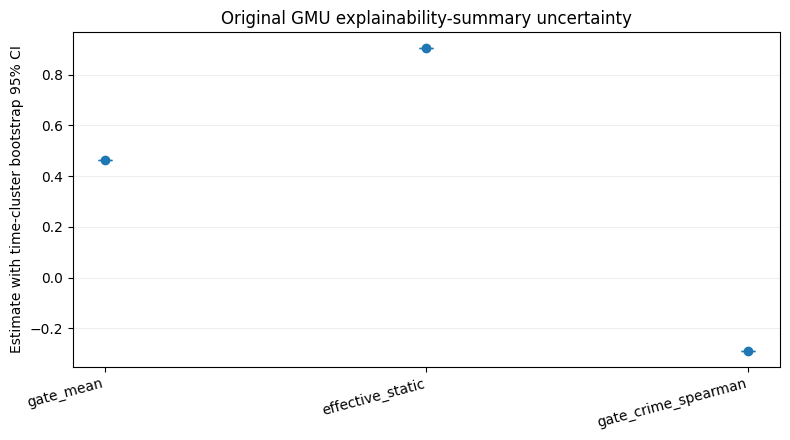

In [50]:
def gmu_cluster_bootstrap(frame, cluster_col="time_id", n_bootstrap=1000, random_seed=42):
    rng = np.random.default_rng(random_seed)
    clusters = frame[cluster_col].drop_duplicates().to_numpy()
    estimates = []
    for _ in range(n_bootstrap):
        sampled = rng.choice(clusters, size=len(clusters), replace=True)
        boot = pd.concat([frame.loc[frame[cluster_col] == c] for c in sampled], ignore_index=True)
        estimates.append({
            "gate_mean": boot["gmu_static_gate"].mean(),
            "effective_static": boot["static_activation_proportion"].mean(),
            "gate_crime_spearman": association_stats(
                boot["input_crime"], boot["gmu_static_gate"]
            )["spearman_rho"],
        })
    samples = pd.DataFrame(estimates)
    point = {
        "gate_mean": frame["gmu_static_gate"].mean(),
        "effective_static": frame["static_activation_proportion"].mean(),
        "gate_crime_spearman": association_stats(
            frame["input_crime"], frame["gmu_static_gate"]
        )["spearman_rho"],
    }
    summary = pd.DataFrame([{
        "quantity": col, "estimate": point[col],
        "bootstrap_ci95_low": samples[col].quantile(0.025),
        "bootstrap_ci95_high": samples[col].quantile(0.975),
        "bootstrap_std": samples[col].std(ddof=1),
    } for col in samples.columns])
    return summary, samples


gmu_bootstrap_summary, gmu_bootstrap_samples = gmu_cluster_bootstrap(
    gmu_explain_frame, n_bootstrap=1000, random_seed=seed
)
display(gmu_bootstrap_summary.round(5))
plt.figure(figsize=(8, 4.5))
x = np.arange(len(gmu_bootstrap_summary))
lower = gmu_bootstrap_summary["estimate"]-gmu_bootstrap_summary["bootstrap_ci95_low"]
upper = gmu_bootstrap_summary["bootstrap_ci95_high"]-gmu_bootstrap_summary["estimate"]
plt.errorbar(x, gmu_bootstrap_summary["estimate"], yerr=np.vstack([lower, upper]),
             fmt="o", capsize=5, linewidth=2)
plt.xticks(x, gmu_bootstrap_summary["quantity"], rotation=15, ha="right")
plt.ylabel("Estimate with time-cluster bootstrap 95% CI")
plt.title("Original GMU explainability-summary uncertainty")
plt.grid(axis="y", alpha=0.2); plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_gate_bootstrap_ci.png"), dpi=300, bbox_inches="tight")
plt.show()
gmu_bootstrap_summary.to_csv(os.path.join(output_folder, "gmu_gate_bootstrap_ci.csv"), index=False)

### Easy explanation — bootstrap confidence intervals

**Purpose.** Complete test windows are resampled to estimate variability across the available
test periods.

GMU's intervals are extremely narrow: gate mean is approximately 0.46436–0.46437, effective
static contribution 0.90685–0.90723, and gate–crime Spearman −0.29188 to −0.28930. These
summaries are stable across test windows.

**Compared with M11.** M11 also has very narrow window-bootstrap intervals. Neither model
wins meaningfully here. These intervals do not include retraining randomness; compare 5–10
matched seeds for architectural confidence.


## M. Exportable summary for fair GMU–M11 comparison

Common columns below can be compared across models. M11 should export separate self and
neighbor rows or a declared primary role; GMU has exactly one row. Never fill absent GMU
self/neighbor statistics with invented values.

In [51]:
learned_row = gmu_gate_interventions.query("intervention == 'Learned gate'").iloc[0]
balanced_row = gmu_gate_interventions.query("intervention == 'Balanced gate (0.5)'").iloc[0]
shuffled_row = gmu_gate_interventions.query("intervention == 'Shuffled learned gate logits'").iloc[0]
input_assoc = gmu_gate_crime_associations.query("crime_variable == 'input_crime'").iloc[0]

gmu_model_explainability_summary = pd.DataFrame([{
    "model": "Original GMU only",
    "uses_graph": False,
    "gate_role": "single_pre_regression_fusion_gate",
    "test_MSE": metrics["MSE"], "test_RMSE": metrics["RMSE"],
    "test_MAE": metrics["MAE"], "test_R2": metrics["R2"],
    "static_only_MSE": static_metrics["MSE"], "dynamic_only_MSE": dynamic_metrics["MSE"],
    "static_gate_mean": gmu_explain_frame["gmu_static_gate"].mean(),
    "gate_std_featurewise": gmu_gate_health["global_std"].iloc[0],
    "gate_entropy": gmu_gate_health["mean_entropy_0_to_1"].iloc[0],
    "gate_input_crime_spearman": input_assoc["spearman_rho"],
    "effective_static_proportion": gmu_explain_frame["static_activation_proportion"].mean(),
    "balanced_gate_delta_MSE": balanced_row["MSE"]-learned_row["MSE"],
    "shuffled_gate_delta_MSE": shuffled_row["MSE"]-learned_row["MSE"],
    "self_neighbor_analysis_available": False,
}])
display(gmu_model_explainability_summary.T)
gmu_model_explainability_summary.to_csv(
    os.path.join(output_folder, "gmu_professional_model_explainability_summary.csv"), index=False
)

,0
model,Original GMU only
uses_graph,False
gate_role,single_pre_regression_fusion_gate
test_MSE,0.000054
test_RMSE,0.007357
test_MAE,0.003739
test_R2,0.981342
static_only_MSE,0.003668
dynamic_only_MSE,0.000084
static_gate_mean,0.464365


## Overall GMU versus M11 conclusion

| Analysis | Original GMU | Normalized M11 | Better and why |
|---|---:|---:|---|
| Test MSE | **0.000054** | 0.000065 | GMU: lower forecast error |
| Test MAE | **0.003739** | 0.005234 | GMU: lower average error |
| Test R² | **0.981342** | 0.977696 | GMU: slightly more explained variation |
| Parameters | **10,689** | 36,033 | GMU: simpler and smaller |
| Full vs dynamic-only relative MSE reduction | 36% | **50%** | M11: stronger fusion complementarity |
| Feature-wise gate standard deviation | 0.064 | **0.285 self / 0.202 neighbor** | M11: stronger specialization |
| Gate entropy | 0.984 | **0.719 / 0.872** | M11: less indecisive gates |
| Gate–crime behavior | −0.291 | **−0.659 self; +0.348 neighbor** | M11: stronger, role-specific behavior |
| Effective static magnitude | 90.7% | **52.8% / 56.2%** | M11: balanced and interpretable scale |
| Shuffled-gate relative MSE increase | 485% | **5,463%** | M11: stronger routing faithfulness |
| Self/neighbor separation | Not available | **Available** | M11: unique message-passing capability |
| Graph use | No | **Yes** | M11: models street-network interaction |

### Which model is better?

There are two honest answers:

1. **For forecasting accuracy in these saved runs, original GMU is better.** It has lower
   MSE, RMSE and MAE, higher R², fewer parameters, and converges faster.
2. **For your modality-fusion research claim, M11 is better.** It balances branch magnitudes,
   learns much stronger feature-wise specialization, separates self from neighbor behavior,
   responds more clearly to crime intensity, uses a broader set of inputs, and depends more
   strongly on correct gate routing.

### Why GMU can predict better despite weaker-looking gates

Prominent gates are not required for accurate prediction. GMU can use soft gates and let the
encoders/regressor learn an effective forecasting transformation. Its strong reliance on lag
1 may be especially effective for this highly autoregressive task. M11 solves a harder problem:
it learns both modality fusion and graph-neighborhood propagation.

### Defensible paper conclusion

> Original GMU achieved the best single-run forecasting accuracy, demonstrating that simple
> node-level intermediate fusion is a strong baseline. The proposed M11 model produced slightly
> higher prediction error but substantially stronger and more interpretable role-specific
> modality behavior. In particular, M11 balanced activation scales, distinguished self from
> neighborhood fusion, and showed stronger gate specialization and intervention faithfulness.

Do not yet write that either model is statistically superior. Run both with the same data
splits, checkpoint policy, hyperparameter-selection procedure, and 5–10 matched random seeds.
Report predictive superiority separately from explainability/architectural capability.


## Interpretation framework after running the notebook

Use prediction and explanation evidence separately:

1. **Predictive quality:** report MSE, RMSE, MAE and R² across matched seeds.
2. **Complementarity:** compare full input with post-hoc ablations and independently trained
   unimodal baselines.
3. **Gate health:** reject collapse only when gates vary and interventions are faithful.
4. **Conditional behavior:** report gate–crime effect sizes, not p-values alone.
5. **Mechanistic scale:** compare raw gates with effective activation proportions.
6. **Faithfulness:** emphasize shuffled-gate degradation over extreme fixed-gate results.
7. **Original-feature evidence:** use permutation importance while acknowledging correlation.
8. **Uncertainty:** time bootstrap does not replace 5–10 matched training seeds.

For the final GMU–M11 comparison, use identical preprocessing, chronological splits, training
selection rules, hidden dimension, optimizer search policy, seeds and prediction metrics.
M11-specific self/neighbor evidence should be reported as an additional architectural
capability, not as a missing score assigned to GMU.